In [1]:
import pandas as pd
import numpy as np

# Verileri yüklüyoruz
train = pd.read_csv('train.csv')
test_x = pd.read_csv('test_x.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print("Veriler başarıyla yüklendi!")

Veriler başarıyla yüklendi!


Veriyi Keşfetme

In [2]:
# Veri setlerinin boyutlarına bakalım
print("=" * 50)
print("VERİ SETLERİNİN BOYUTLARI")
print("=" * 50)
print(f"Train verisi: {train.shape[0]} satır, {train.shape[1]} sütun")
print(f"Test verisi: {test_x.shape[0]} satır, {test_x.shape[1]} sütun")
print(f"Sample submission: {sample_sub.shape[0]} satır, {sample_sub.shape[1]} sütun")

print("\n" + "=" * 50)
print("TRAIN VERİSİNİN İLK 5 SATIRI")
print("=" * 50)
print(train.head())

print("\n" + "=" * 50)
print("SÜTUN BİLGİLERİ VE VERİ TİPLERİ")
print("=" * 50)
print(train.info())

print("\n" + "=" * 50)
print("EKSİK DEĞER KONTROLÜ")
print("=" * 50)
print(train.isnull().sum())

print("\n" + "=" * 50)
print("SAYISAL SÜTUNLARIN İSTATİSTİKLERİ")
print("=" * 50)
print(train.describe())

VERİ SETLERİNİN BOYUTLARI
Train verisi: 56000 satır, 24 sütun
Test verisi: 24000 satır, 23 sütun
Sample submission: 2 satır, 2 sütun

TRAIN VERİSİNİN İLK 5 SATIRI
   id  yas cinsiyet            meslek  vucut_kitle_indeksi          ulke  \
0   1   34    Erkek  Saglik Personeli            31.470103           Cin   
1   2   32    Kadin          Muhendis            30.981394       Amerika   
2   3   39    Erkek         Ev Hanimi            21.533898         Spain   
3   4   40    Kadin          Egitimci            23.310749  Yeni Zelanda   
4   5   36    Kadin               NaN                  NaN      Portekiz   

   rem_yuzdesi  derin_uyku_yuzdesi  uykuya_dalma_suresi_dk  \
0    14.431210           14.645436                      27   
1    21.771870           27.220360                      20   
2    18.178857           25.530104                      33   
3    21.438151           15.891188                      21   
4    25.468018           16.356738                      21   

   gece

Basit Bir Baseline Model (İlk Deneme)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Hedef değişkeni ayıralım
X = train.drop(['id', 'bilissel_performans_skoru'], axis=1)
y = train['bilissel_performans_skoru']

# Test verisinden id'yi ayıralım
test_ids = test_x['id']
X_test = test_x.drop(['id'], axis=1)

print("✅ Hedef değişken ayrıldı")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_test shape: {X_test.shape}")

✅ Hedef değişken ayrıldı
X shape: (56000, 22)
y shape: (56000,)
X_test shape: (24000, 22)


Veri Ön İşleme (Data Preprocessing): Eksik değerleri doldurup, kategorik değişkenleri sayısala çevireceğiz.

In [4]:
# Numerik ve kategorik sütunları ayıralım
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("=" * 50)
print("SÜTUN TİPLERİ")
print("=" * 50)
print(f"Sayısal sütunlar ({len(numeric_cols)}): {numeric_cols}")
print(f"\nKategorik sütunlar ({len(categorical_cols)}): {categorical_cols}")

# Train ve Test için kopyalar oluşturalım
X_train_processed = X.copy()
X_test_processed = X_test.copy()

# 1) EKSİK DEĞER DOLDURMA
print("\n" + "=" * 50)
print("EKSİK DEĞERLER DOLDURULUYOR...")
print("=" * 50)

# Sayısal sütunlar için: medyan ile doldur
for col in numeric_cols:
    median_value = X_train_processed[col].median()
    X_train_processed[col].fillna(median_value, inplace=True)
    X_test_processed[col].fillna(median_value, inplace=True)

# Kategorik sütunlar için: mod (en sık tekrar eden) ile doldur
for col in categorical_cols:
    mode_value = X_train_processed[col].mode()[0]
    X_train_processed[col].fillna(mode_value, inplace=True)
    X_test_processed[col].fillna(mode_value, inplace=True)

print("✅ Eksik değerler dolduruldu!")

# 2) KATEGORİK DEĞİŞKENLERİ SAYISALA ÇEVİRME (Label Encoding)
from sklearn.preprocessing import LabelEncoder

print("\n" + "=" * 50)
print("KATEGORİK DEĞİŞKENLER SAYISALA ÇEVRİLİYOR...")
print("=" * 50)

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    # Train ve Test'i birleştirip fit ediyoruz (tüm kategorileri öğrensin)
    combined = pd.concat([X_train_processed[col], X_test_processed[col]])
    le.fit(combined)

    X_train_processed[col] = le.transform(X_train_processed[col])
    X_test_processed[col] = le.transform(X_test_processed[col])

    label_encoders[col] = le

print("✅ Kategorik değişkenler sayısala çevrildi!")

# Kontrol edelim
print("\n" + "=" * 50)
print("İŞLENMİŞ VERİ KONTROLÜ")
print("=" * 50)
print(f"Train eksik değer sayısı: {X_train_processed.isnull().sum().sum()}")
print(f"Test eksik değer sayısı: {X_test_processed.isnull().sum().sum()}")
print(f"\nİlk 3 satır:")
print(X_train_processed.head(3))

SÜTUN TİPLERİ
Sayısal sütunlar (15): ['yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat']

Kategorik sütunlar (7): ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']

EKSİK DEĞERLER DOLDURULUYOR...
✅ Eksik değerler dolduruldu!

KATEGORİK DEĞİŞKENLER SAYISALA ÇEVRİLİYOR...


/tmp/ipykernel_3589/3166395131.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_processed[col].fillna(median_value, inplace=True)
/tmp/ipykernel_3589/3166395131.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

✅ Kategorik değişkenler sayısala çevrildi!

İŞLENMİŞ VERİ KONTROLÜ
Train eksik değer sayısı: 0
Test eksik değer sayısı: 0

İlk 3 satır:
   yas  cinsiyet  meslek  vucut_kitle_indeksi  ulke  rem_yuzdesi  \
0   34         0       7            31.470103     2    14.431210   
1   32         1       5            30.981394     0    21.771870   
2   39         0       2            21.533898    12    18.178857   

   derin_uyku_yuzdesi  uykuya_dalma_suresi_dk  gecelik_uyanma_sayisi  \
0           14.645436                      27                      7   
1           27.220360                      20                      4   
2           25.530104                      33                      7   

   uyku_oncesi_kafein_mg  ...  sekerleme_suresi_dk  stres_skoru  \
0                    0.0  ...                    0     9.922976   
1                    4.0  ...                    1     6.626400   
2                  148.0  ...                   70     6.093566   

   gunluk_calisma_saati  kronotip

Train/Validation Bölme ve Model Eğitimi

In [5]:
# Veriyi train ve validation olarak bölelim (%80 train, %20 validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_processed,
    y,
    test_size=0.2,
    random_state=42
)

print("=" * 50)
print("VERİ BÖLÜNDÜ")
print("=" * 50)
print(f"Train seti: {X_train.shape[0]} satır")
print(f"Validation seti: {X_val.shape[0]} satır")

# RandomForest modeli oluşturalım
print("\n" + "=" * 50)
print("MODEL EĞİTİLİYOR...")
print("=" * 50)

model = RandomForestRegressor(
    n_estimators=100,      # 100 ağaç
    max_depth=15,          # Maksimum derinlik
    random_state=42,
    n_jobs=-1              # Tüm CPU çekirdeklerini kullan
)

# Modeli eğitelim
model.fit(X_train, y_train)

print("✅ Model eğitildi!")

# Validation seti üzerinde tahmin yapalım
y_val_pred = model.predict(X_val)

# RMSE hesaplayalım
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print("\n" + "=" * 50)
print("SONUÇLAR (VALIDATION SETİ)")
print("=" * 50)
print(f"🎯 RMSE: {rmse:.4f}")
print("\nÖrnek tahminler:")
comparison = pd.DataFrame({
    'Gerçek': y_val.values[:10],
    'Tahmin': y_val_pred[:10],
    'Fark': np.abs(y_val.values[:10] - y_val_pred[:10])
})
print(comparison)

VERİ BÖLÜNDÜ
Train seti: 44800 satır
Validation seti: 11200 satır

MODEL EĞİTİLİYOR...
✅ Model eğitildi!

SONUÇLAR (VALIDATION SETİ)
🎯 RMSE: 1.2889

Örnek tahminler:
     Gerçek    Tahmin      Fark
0  4.096446  4.892511  0.796066
1  8.194825  7.071130  1.123695
2  4.847568  4.700851  0.146717
3  5.606995  7.300750  1.693755
4  8.666087  8.762365  0.096278
5  7.715355  7.165770  0.549585
6  3.654145  4.439946  0.785801
7  2.310188  4.602753  2.292565
8  4.906085  4.104266  0.801820
9  6.457942  5.265940  1.192001


In [6]:
# Test verisi üzerinde tahmin yapalım
print("=" * 50)
print("TEST VERİSİ İÇİN TAHMİN YAPILIYOR...")
print("=" * 50)

y_test_pred = model.predict(X_test_processed)

print(f"✅ {len(y_test_pred)} tahmin üretildi!")

# Submission dosyası oluşturalım
submission = pd.DataFrame({
    'id': test_ids,
    'bilissel_performans_skoru': y_test_pred
})

print("\n" + "=" * 50)
print("SUBMİSSİON DOSYASI")
print("=" * 50)
print(f"Satır sayısı: {len(submission)}")
print("\nİlk 10 tahmin:")
print(submission.head(10))

print("\nTahminlerin istatistikleri:")
print(submission['bilissel_performans_skoru'].describe())

# Dosyayı kaydedelim
submission.to_csv('submission.csv', index=False)

print("\n" + "=" * 50)
print("✅ DOSYA KAYDEDİLDİ: submission.csv")
print("=" * 50)

TEST VERİSİ İÇİN TAHMİN YAPILIYOR...
✅ 24000 tahmin üretildi!

SUBMİSSİON DOSYASI
Satır sayısı: 24000

İlk 10 tahmin:
   id  bilissel_performans_skoru
0   1                   6.172281
1   2                   6.069489
2   3                   3.884978
3   4                   7.247559
4   5                   3.931069
5   6                   5.189595
6   7                   3.683311
7   8                   7.086917
8   9                   3.462798
9  10                   4.281133

Tahminlerin istatistikleri:
count    24000.000000
mean         5.939087
std          1.770561
min          0.707682
25%          4.697513
50%          6.014092
75%          7.252706
max          9.823217
Name: bilissel_performans_skoru, dtype: float64

✅ DOSYA KAYDEDİLDİ: submission.csv

📥 Sol panelden 'submission.csv' dosyasını indirebilirsin!


------Derinlemesine EDA--------

EDA Bölüm 1: Hedef Değişken ve Eksik Değerler

1. HEDEF DEĞİŞKEN DAĞILIMI


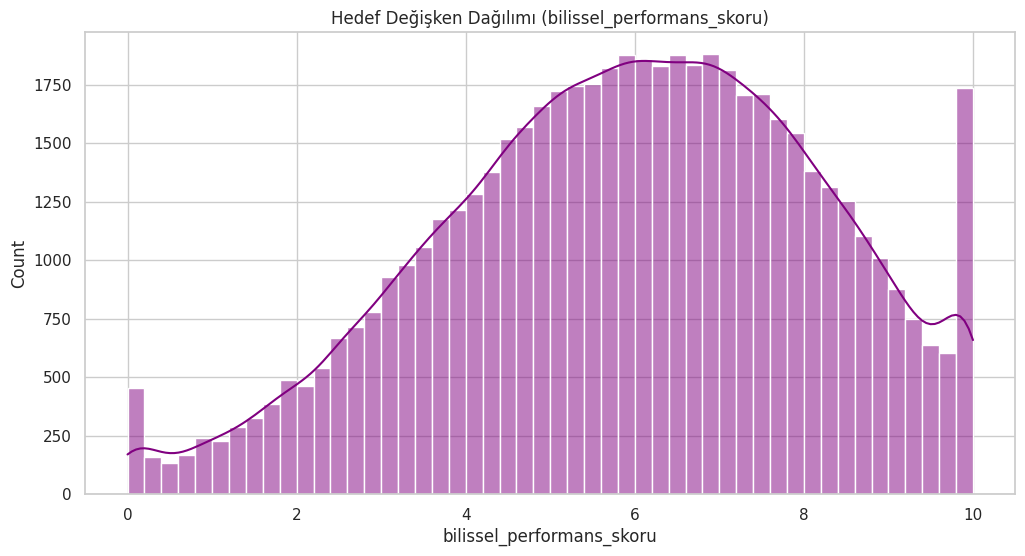


2. EKSİK DEĞER HARİTASI


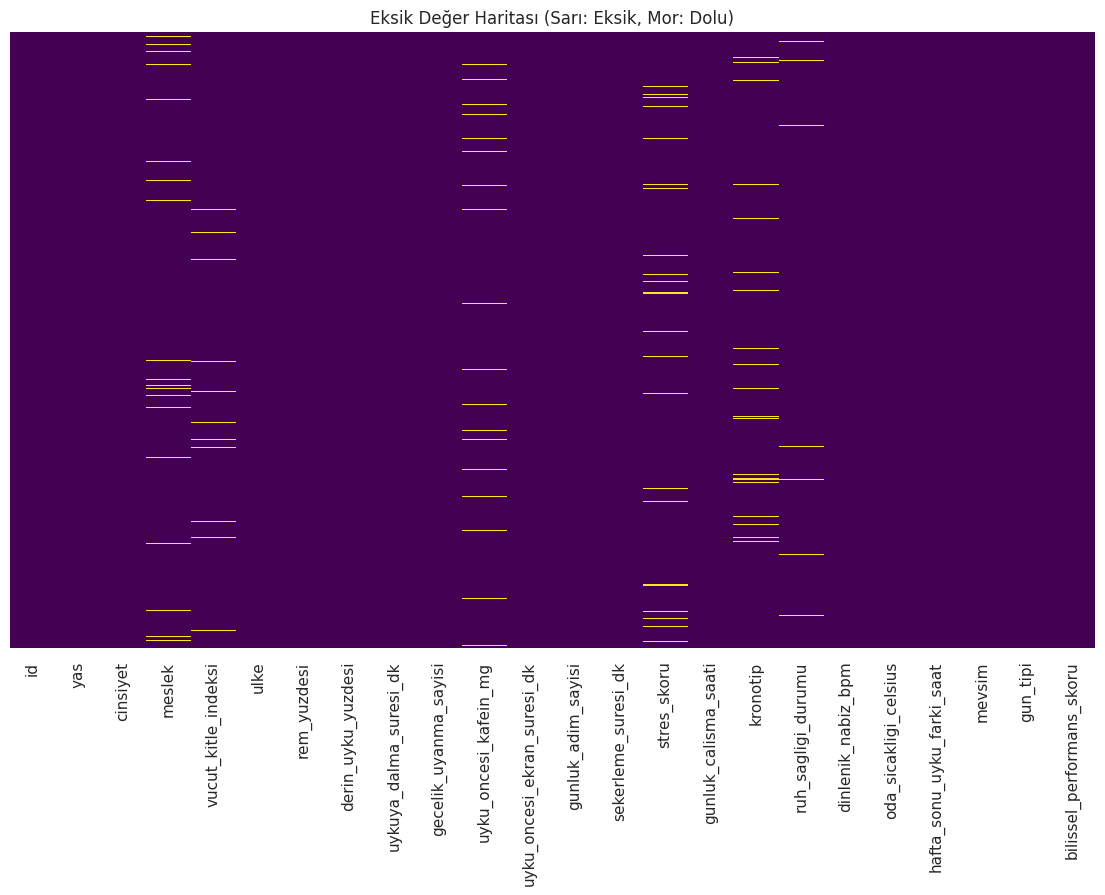

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Görsel ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("1. HEDEF DEĞİŞKEN DAĞILIMI")
plt.figure()
sns.histplot(train['bilissel_performans_skoru'], kde=True, bins=50, color='purple')
plt.title('Hedef Değişken Dağılımı (bilissel_performans_skoru)')
plt.show()

print("\n2. EKSİK DEĞER HARİTASI")
plt.figure(figsize=(14, 8))
sns.heatmap(train.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Eksik Değer Haritası (Sarı: Eksik, Mor: Dolu)')
plt.show()

EDA Bölüm 2: Sayısal Değişkenler ve Aykırı Değerler (Outliers)

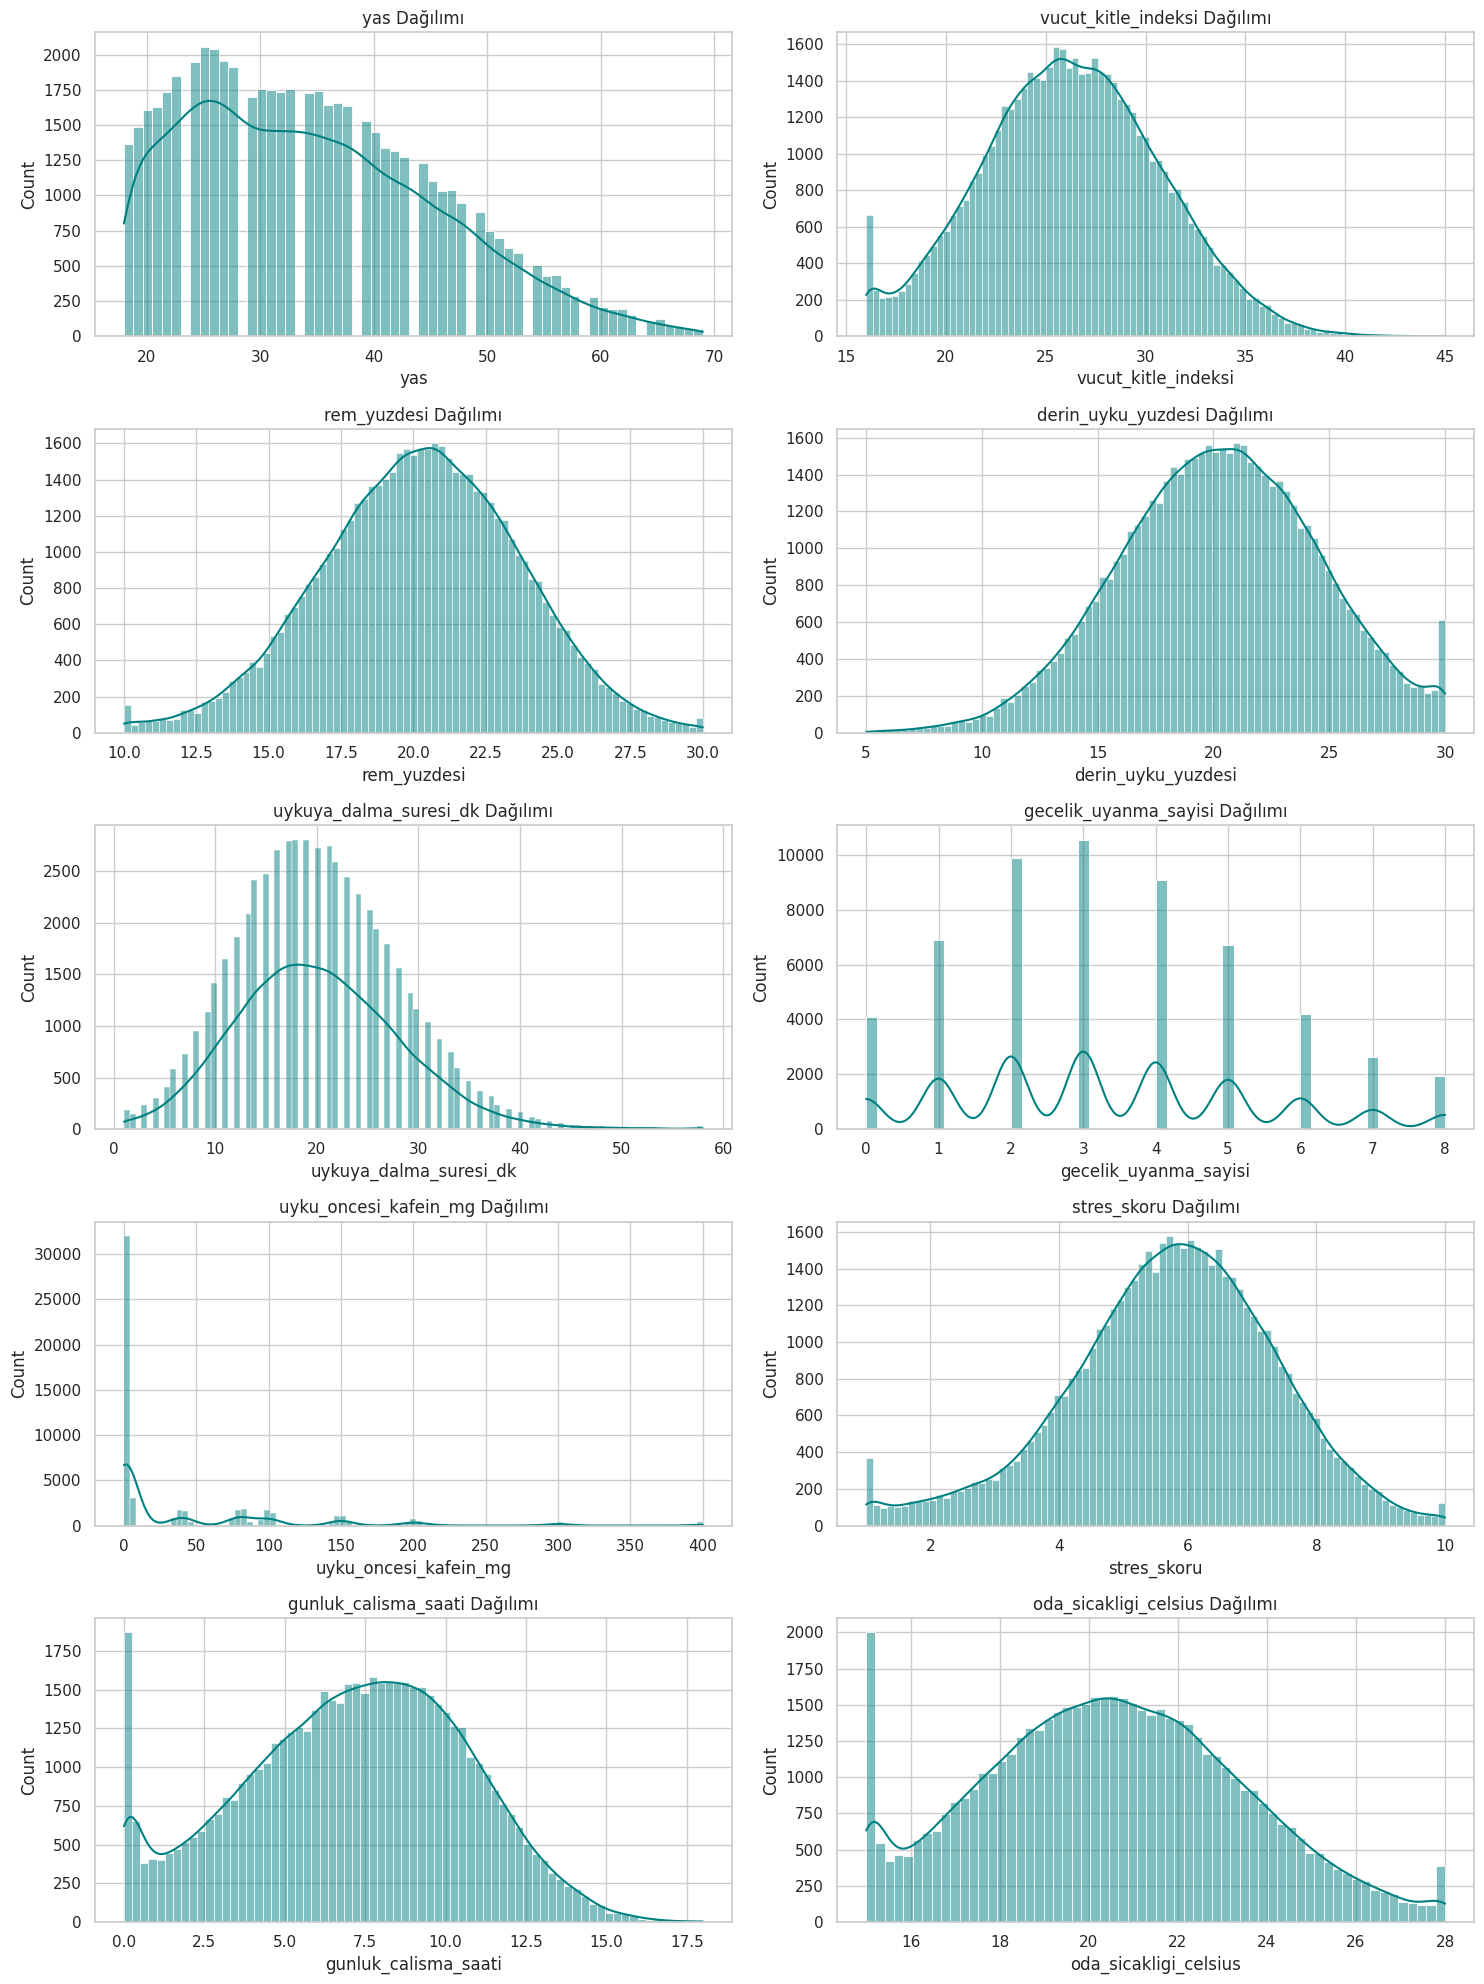


AYKIRI DEĞER KONTROLÜ (BOXPLOT)


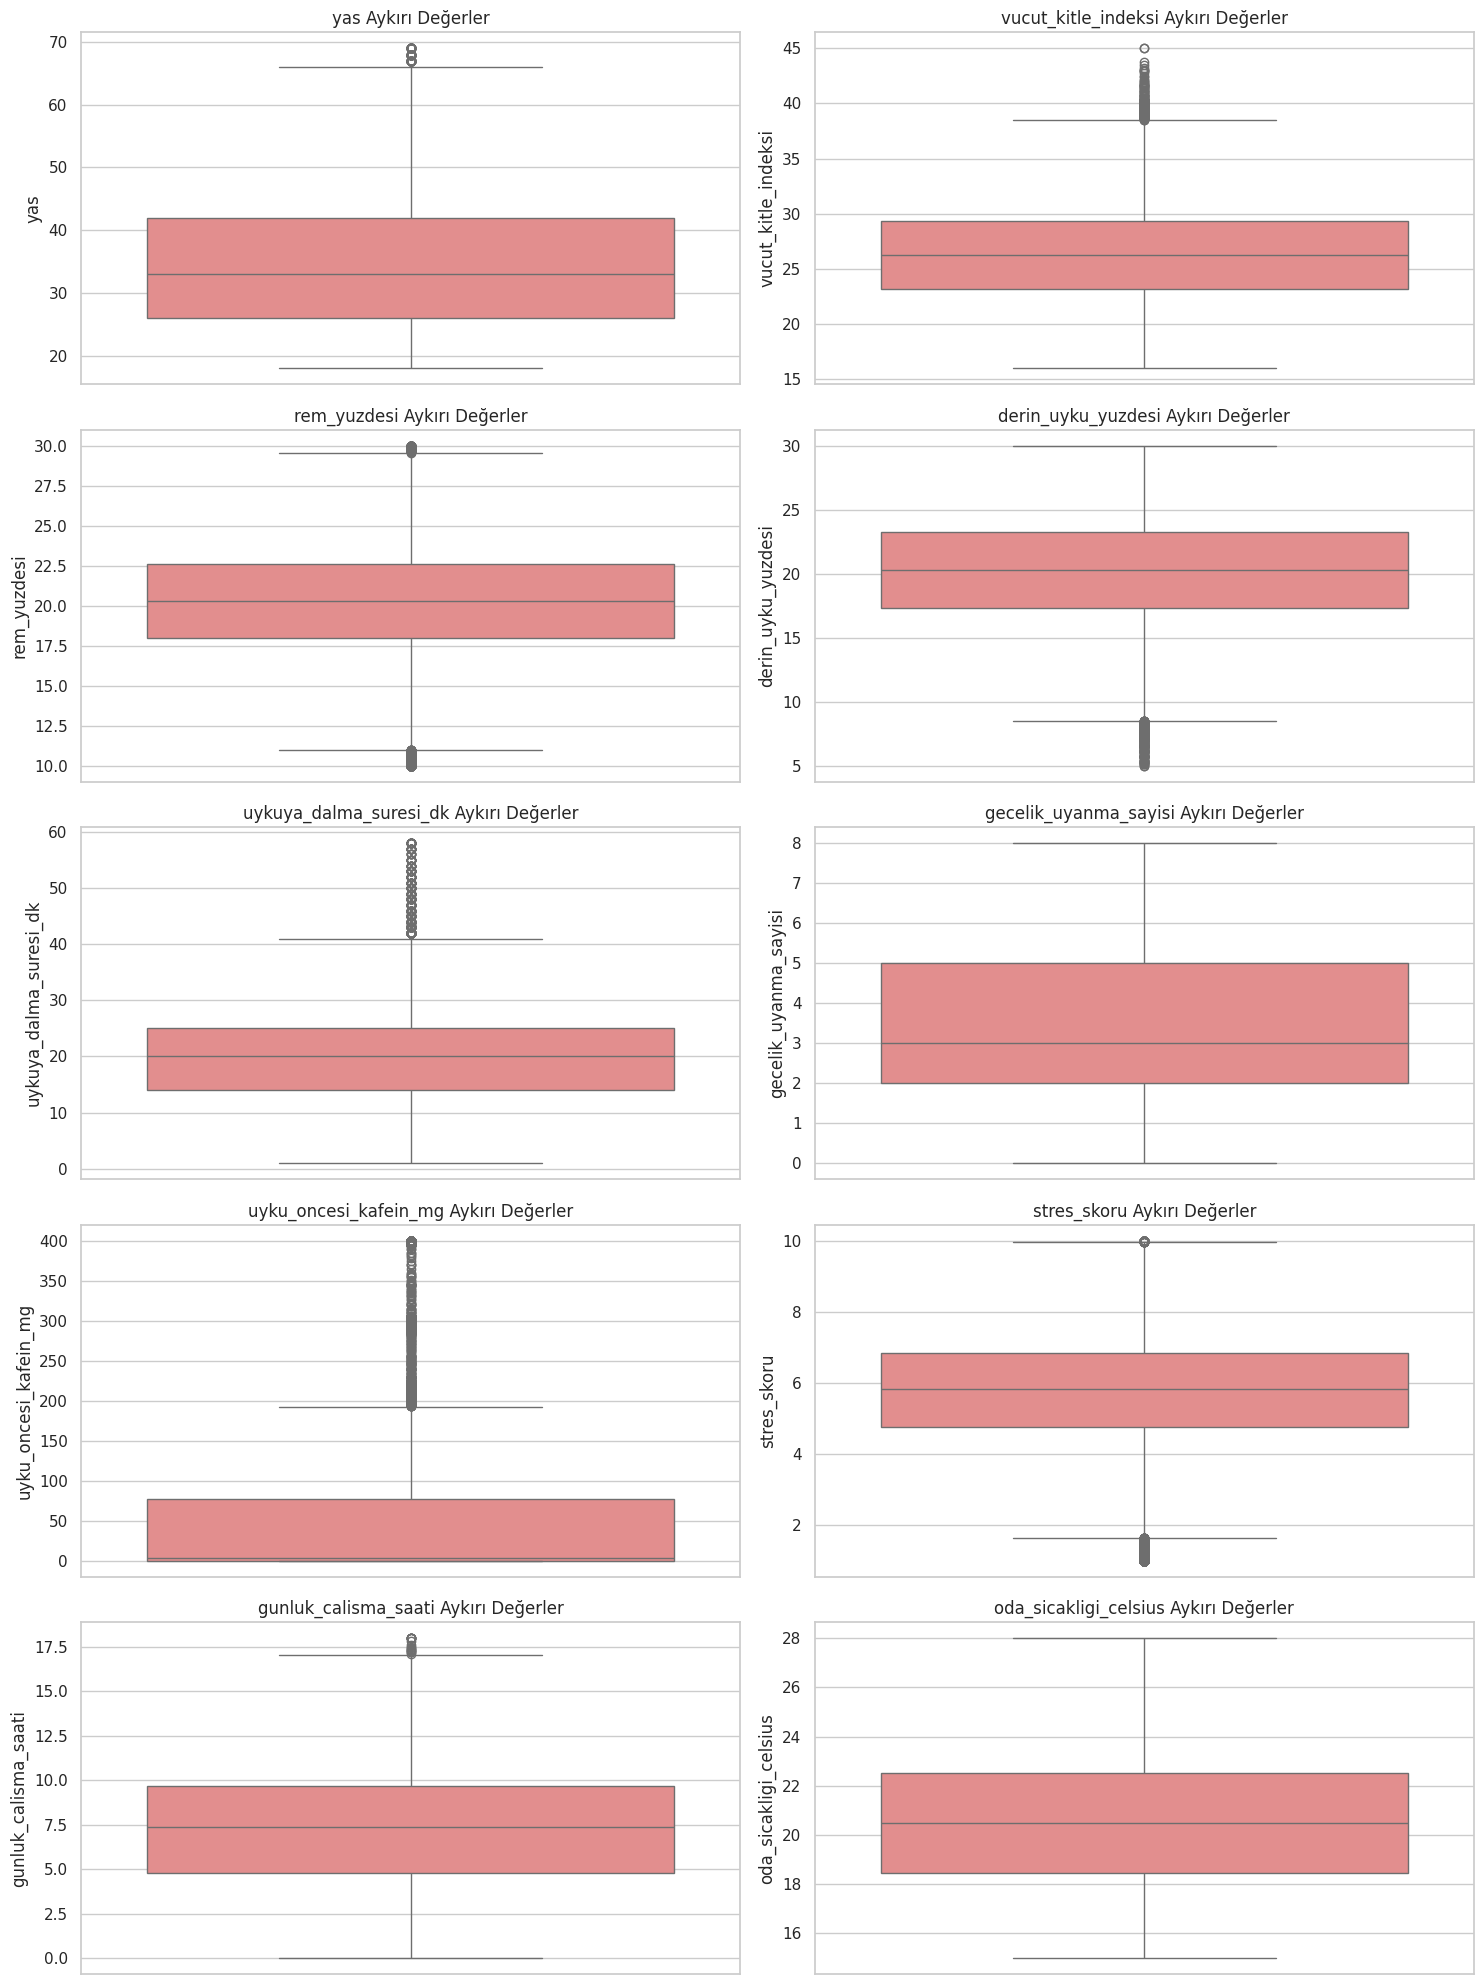

In [8]:
numeric_cols = ['yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi',
                'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg',
                'stres_skoru', 'gunluk_calisma_saati', 'oda_sicakligi_celsius']

# Sayısal değişkenlerin dağılımı
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(train[col].dropna(), kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'{col} Dağılımı')
plt.tight_layout()
plt.show()

# Aykırı Değerler (Boxplot)
print("\nAYKIRI DEĞER KONTROLÜ (BOXPLOT)")
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=train[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{col} Aykırı Değerler')
plt.tight_layout()
plt.show()

EDA Bölüm 3: Kategorik Değişkenler

/tmp/ipykernel_3589/3057960144.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train[col], ax=axes[i], order=train[col].value_counts().index, palette='Set2')
/tmp/ipykernel_3589/3057960144.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train[col], ax=axes[i], order=train[col].value_counts().index, palette='Set2')
/tmp/ipykernel_3589/3057960144.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train[col], ax=axes[i], order=train[col].value_counts().index, palette='Set2')
/tmp/ipykernel_3589/3057960144.py:7: FutureWarnin

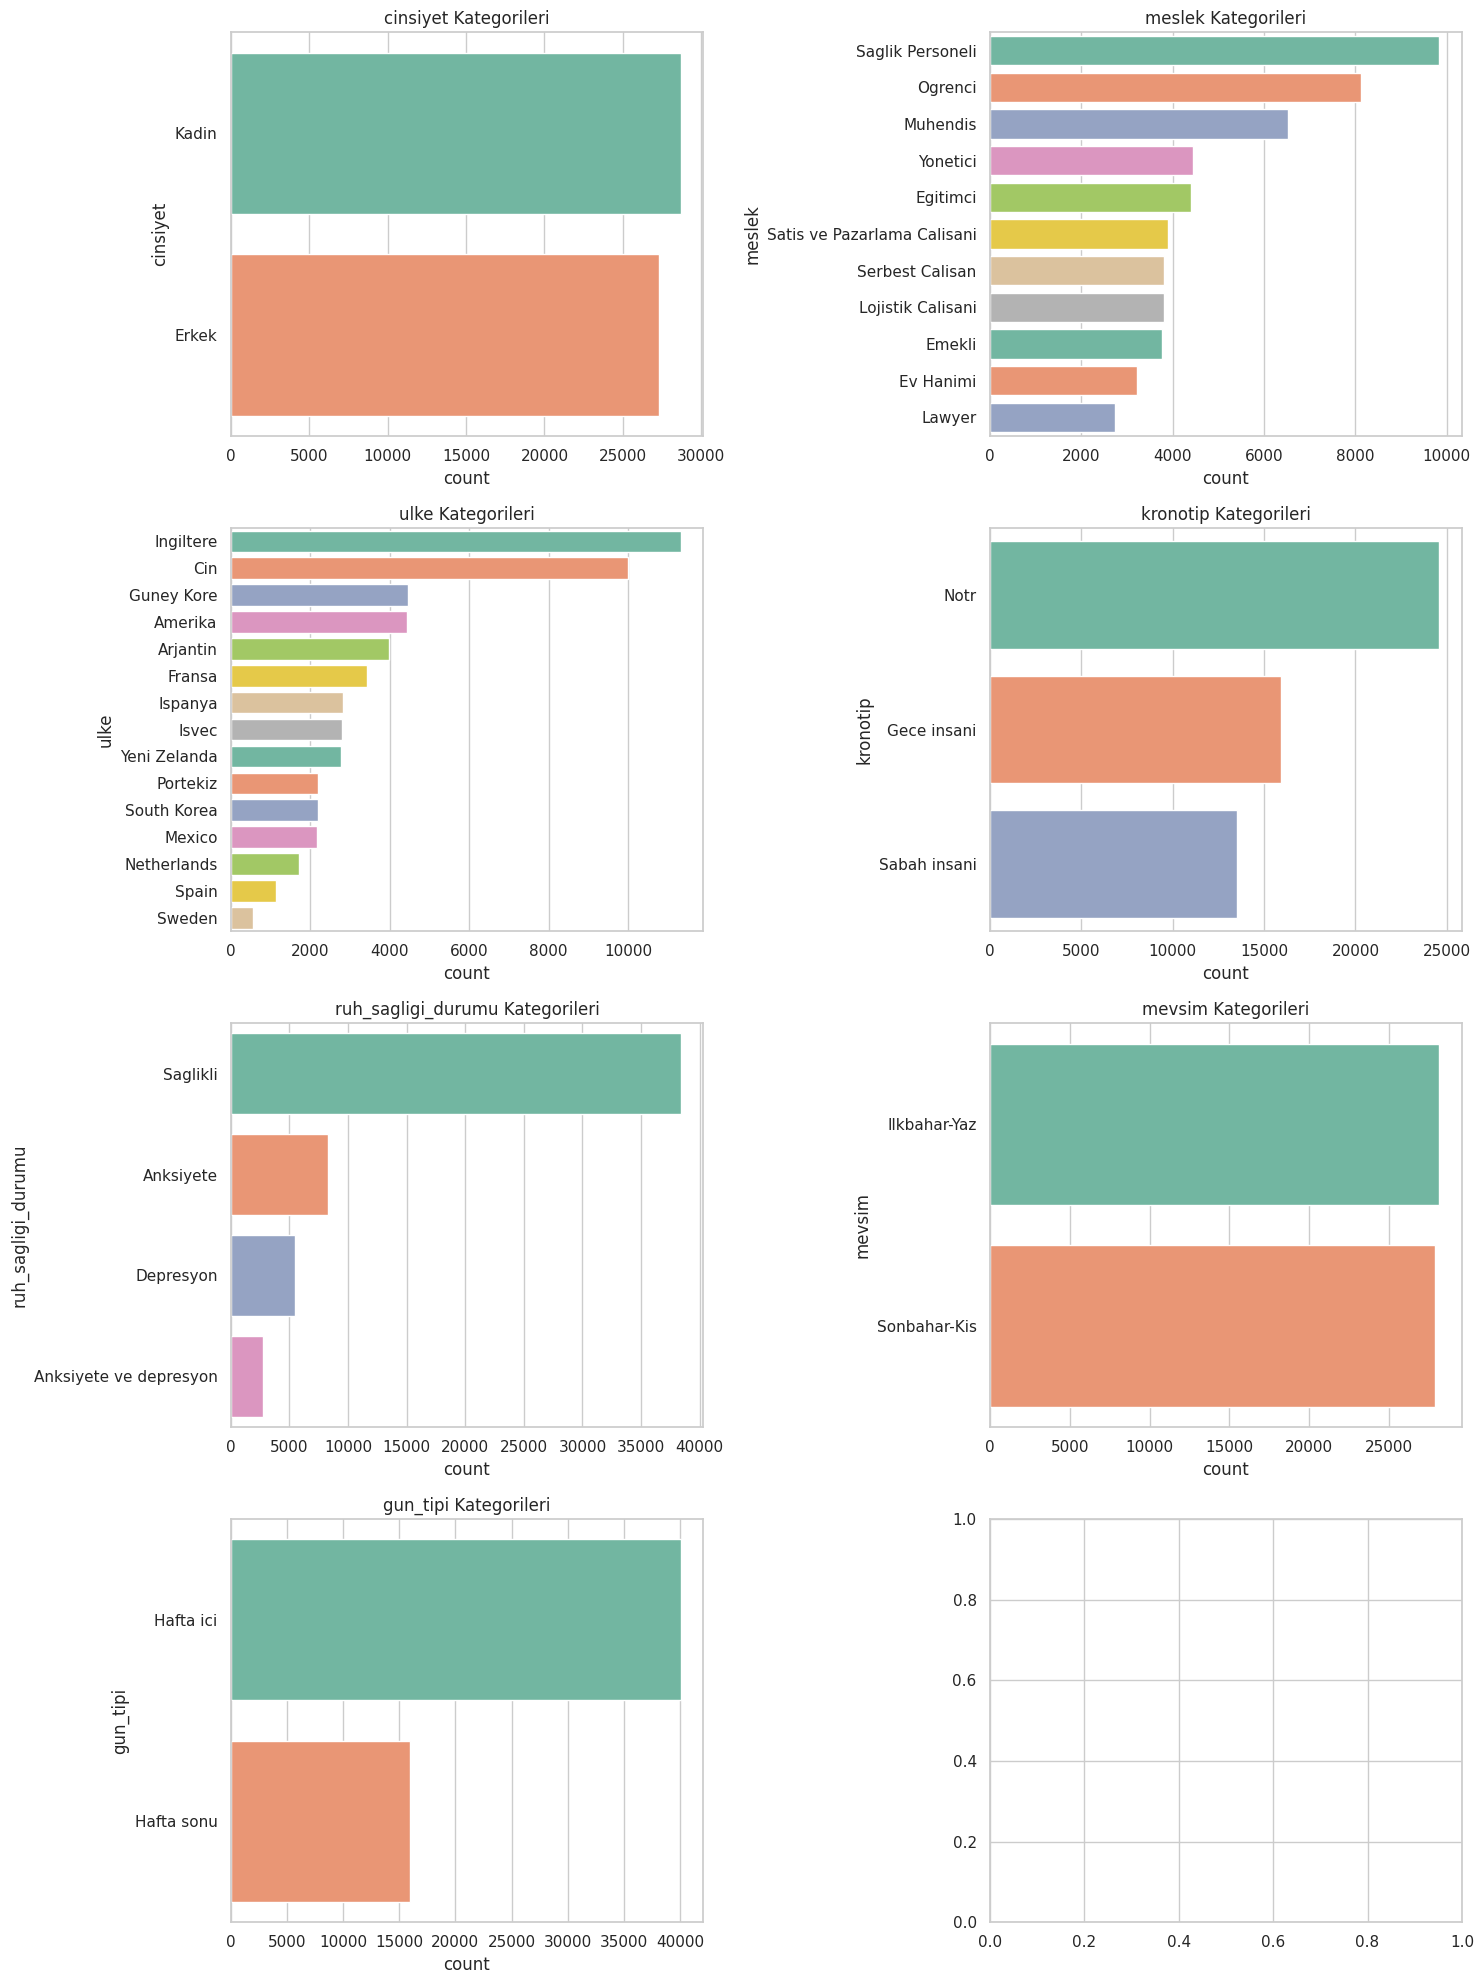

In [9]:
categorical_cols = ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    # Sıralı ve okunaklı olması için
    sns.countplot(y=train[col], ax=axes[i], order=train[col].value_counts().index, palette='Set2')
    axes[i].set_title(f'{col} Kategorileri')
plt.tight_layout()
plt.show()

ADIM 1.b-d-e: Profesyonel Veri Ön İşleme Pipeline

In [10]:
# ÖNCEKİ İŞLENMİŞ VERİLERİ UNUTALIM - YENİDEN BAŞLIYORUZ
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Hedef değişkeni ayıralım
X = train.drop(['id', 'bilissel_performans_skoru'], axis=1).copy()
y = train['bilissel_performans_skoru'].copy()

X_test = test_x.drop(['id'], axis=1).copy()
test_ids = test_x['id'].copy()

print("=" * 60)
print("YENİ PİPELİNE BAŞLIYOR (PROFESYONEL YÖNTEMLERLE)")
print("=" * 60)
print(f"Train: {X.shape}, Test: {X_test.shape}")

YENİ PİPELİNE BAŞLIYOR (PROFESYONEL YÖNTEMLERLE)
Train: (56000, 22), Test: (24000, 22)


1.b) Eksik Değer İşleme + Eksiklik İndikatörleri

In [11]:
# Eksik değerleri işaretle (1=eksik, 0=dolu)
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[f'{col}_missing'] = X[col].isnull().astype(int)
        X_test[f'{col}_missing'] = X_test[col].isnull().astype(int)

print("✅ Eksiklik indikatörleri eklendi")

# Sütun tiplerini belirle
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Eksik değerleri doldur
# Sayısal → Median
for col in numeric_cols:
    if col.endswith('_missing'):  # İndikatör sütunlarını atla
        continue
    median_val = X[col].median()
    X[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

# Kategorik → Mode
for col in categorical_cols:
    mode_val = X[col].mode()[0]
    X[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True)

print("✅ Eksik değerler dolduruldu (Median/Mode)")
print(f"Toplam sütun sayısı: {X.shape[1]} (indikatörlerle birlikte)")

✅ Eksiklik indikatörleri eklendi
✅ Eksik değerler dolduruldu (Median/Mode)
Toplam sütun sayısı: 28 (indikatörlerle birlikte)


1.d) Aykırı Değer Temizleme (IQR Capping)

In [12]:
# Aykırı değerleri tırpanlama (Winsorization)
def cap_outliers(df, col, test_df):
    """IQR yöntemiyle aykırı değerleri sınırlar"""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Train'i sınırla
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    # Test'i de aynı sınırlarla sınırla
    test_df[col] = test_df[col].clip(lower=lower_bound, upper=upper_bound)

    return lower_bound, upper_bound

# Kritik sütunları tırpanla
outlier_cols = ['uyku_oncesi_kafein_mg', 'vucut_kitle_indeksi',
                'uykuya_dalma_suresi_dk', 'yas']

for col in outlier_cols:
    lower, upper = cap_outliers(X, col, X_test)
    print(f"✂️ {col}: [{lower:.1f}, {upper:.1f}] aralığına çekildi")

print("\n✅ Aykırı değerler temizlendi")

✂️ uyku_oncesi_kafein_mg: [-114.0, 190.0] aralığına çekildi
✂️ vucut_kitle_indeksi: [14.4, 38.1] aralığına çekildi
✂️ uykuya_dalma_suresi_dk: [-2.5, 41.5] aralığına çekildi
✂️ yas: [2.0, 66.0] aralığına çekildi

✅ Aykırı değerler temizlendi


ADIM 1.e-f: Feature Engineering + Encoding + Scaling

Gelişmiş Encoding Teknikleri

In [13]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("=" * 60)
print("FEATURE ENGINEERING VE ENCODING")
print("=" * 60)

# 1) BASIT KATEGORİLER İÇİN LABEL ENCODING
# (2-3 kategori olanlar: cinsiyet, mevsim, gun_tipi)
simple_categorical = ['cinsiyet', 'mevsim', 'gun_tipi']

for col in simple_categorical:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    X_test[col] = le.transform(X_test[col])

print(f"✅ Basit kategoriler encode edildi: {simple_categorical}")

# 2) FREQUENCY ENCODING (Kategori tekrar sıklığı)
# (Çok kategorili: ulke, meslek, kronotip, ruh_sagligi_durumu)
freq_categorical = ['ulke', 'meslek', 'kronotip', 'ruh_sagligi_durumu']

for col in freq_categorical:
    # Frekansları hesapla
    freq_map = X[col].value_counts(normalize=True).to_dict()

    # Yeni sütun ekle
    X[f'{col}_freq'] = X[col].map(freq_map)
    X_test[f'{col}_freq'] = X_test[col].map(freq_map)

    # Test'te görülmeyen kategoriler için ortalama frekans
    X_test[f'{col}_freq'].fillna(X[f'{col}_freq'].mean(), inplace=True)

print(f"✅ Frekans özellikleri eklendi: {freq_categorical}")

# 3) TARGET ENCODING (Kategorinin hedef değişkenle ortalaması)
# ÖNEMLİ: Data leakage önlemek için sadece train'den öğren!
for col in freq_categorical:
    # Her kategorinin bilissel_performans_skoru ortalaması
    target_map = train.groupby(col)['bilissel_performans_skoru'].mean().to_dict()

    X[f'{col}_target'] = X[col].map(target_map)
    X_test[f'{col}_target'] = X_test[col].map(target_map)

    # Test'te görülmeyen kategoriler için genel ortalama
    global_mean = y.mean()
    X_test[f'{col}_target'].fillna(global_mean, inplace=True)

print(f"✅ Target encoding eklendi: {freq_categorical}")

# 4) Orijinal kategorik sütunları label encoding ile sayıya çevir
for col in freq_categorical:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    X_test[col] = le.transform(X_test[col])

print(f"✅ Orijinal kategoriler de encode edildi")

print(f"\n📊 Yeni sütun sayısı: {X.shape[1]}")
print("İlk 3 satır:")
print(X.head(3))

FEATURE ENGINEERING VE ENCODING
✅ Basit kategoriler encode edildi: ['cinsiyet', 'mevsim', 'gun_tipi']
✅ Frekans özellikleri eklendi: ['ulke', 'meslek', 'kronotip', 'ruh_sagligi_durumu']
✅ Target encoding eklendi: ['ulke', 'meslek', 'kronotip', 'ruh_sagligi_durumu']
✅ Orijinal kategoriler de encode edildi

📊 Yeni sütun sayısı: 36
İlk 3 satır:
   yas  cinsiyet  meslek  vucut_kitle_indeksi  ulke  rem_yuzdesi  \
0   34         0       7            31.470103     2    14.431210   
1   32         1       5            30.981394     0    21.771870   
2   39         0       2            21.533898    12    18.178857   

   derin_uyku_yuzdesi  uykuya_dalma_suresi_dk  gecelik_uyanma_sayisi  \
0           14.645436                    27.0                      7   
1           27.220360                    20.0                      4   
2           25.530104                    33.0                      7   

   uyku_oncesi_kafein_mg  ...  kronotip_missing  ruh_sagligi_durumu_missing  \
0              

Scaling (Ölçeklendirme)

In [14]:
print("\n" + "=" * 60)
print("SCALING (ÖLÇEKLENDİRME)")
print("=" * 60)

# Tüm sütunları ölçeklendir
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# DataFrame'e geri çevir (sütun isimlerini korumak için)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✅ Tüm özellikler standardize edildi (mean=0, std=1)")
print(f"\nÖrnek değerler (ilk 3 satır, ilk 5 sütun):")
print(X_scaled.iloc[:3, :5])


SCALING (ÖLÇEKLENDİRME)
✅ Tüm özellikler standardize edildi (mean=0, std=1)

Örnek değerler (ilk 3 satır, ilk 5 sütun):
        yas  cinsiyet    meslek  vucut_kitle_indeksi      ulke
0 -0.064180 -1.024441  0.547280             1.181150 -0.815345
1 -0.245439  0.976142 -0.147151             1.070230 -1.346400
2  0.388966 -1.024441 -1.188797            -1.074032  1.839930


ADIM 2: FEATURE SELECTION (Özellik Seçimi)

2.a) Korelasyon Analizi

ADIM 2: FEATURE SELECTION

📊 HEDEF DEĞİŞKENLE KORELASYON (En Güçlü 15):
                      feature  correlation  abs_correlation
13                stres_skoru    -0.577827         0.577827
5                 rem_yuzdesi     0.442999         0.442999
35  ruh_sagligi_durumu_target     0.409843         0.409843
31    ruh_sagligi_durumu_freq     0.398161         0.398161
33              meslek_target     0.383888         0.383888
14       gunluk_calisma_saati    -0.342112         0.342112
16         ruh_sagligi_durumu     0.316137         0.316137
21                   gun_tipi     0.305426         0.305426
6          derin_uyku_yuzdesi     0.280006         0.280006
8       gecelik_uyanma_sayisi    -0.270349         0.270349
7      uykuya_dalma_suresi_dk    -0.207818         0.207818
29                meslek_freq    -0.207398         0.207398
2                      meslek    -0.139497         0.139497
11         gunluk_adim_sayisi     0.134042         0.134042
17         dinlenik_nabiz_bp

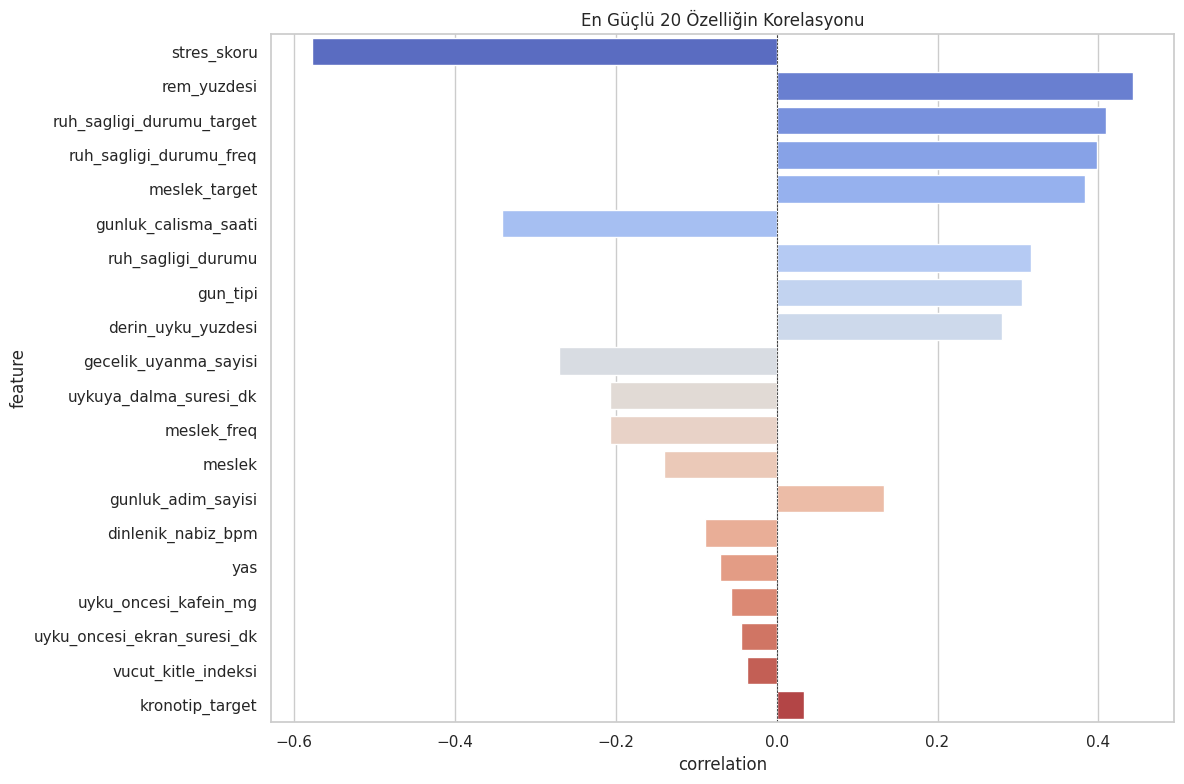

In [15]:
print("=" * 60)
print("ADIM 2: FEATURE SELECTION")
print("=" * 60)

# Hedef değişkenle korelasyonları hesapla
correlations = pd.DataFrame({
    'feature': X_scaled.columns,
    'correlation': [X_scaled[col].corr(y) for col in X_scaled.columns]
})
correlations['abs_correlation'] = correlations['correlation'].abs()
correlations = correlations.sort_values('abs_correlation', ascending=False)

print("\n📊 HEDEF DEĞİŞKENLE KORELASYON (En Güçlü 15):")
print(correlations.head(15))

# Görselleştir
plt.figure(figsize=(12, 8))
top_features = correlations.head(20)
sns.barplot(data=top_features, y='feature', x='correlation', palette='coolwarm')
plt.title('En Güçlü 20 Özelliğin Korelasyonu')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

2.b-e) Feature Importance (RandomForest ile)


FEATURE IMPORTANCE ANALİZİ

🌲 EN ÖNEMLİ 15 ÖZELLİK (RandomForest + ExtraTrees):
                       feature  rf_importance  et_importance  avg_importance
13                 stres_skoru       0.326237       0.213839        0.270038
5                  rem_yuzdesi       0.140991       0.123026        0.132008
21                    gun_tipi       0.058590       0.078300        0.068445
31     ruh_sagligi_durumu_freq       0.031649       0.080842        0.056246
6           derin_uyku_yuzdesi       0.061165       0.049060        0.055113
33               meslek_target       0.027880       0.069221        0.048551
35   ruh_sagligi_durumu_target       0.031393       0.043829        0.037611
8        gecelik_uyanma_sayisi       0.031618       0.040570        0.036094
16          ruh_sagligi_durumu       0.039668       0.025499        0.032584
11          gunluk_adim_sayisi       0.028131       0.019818        0.023975
7       uykuya_dalma_suresi_dk       0.021833       0.017564        0.01

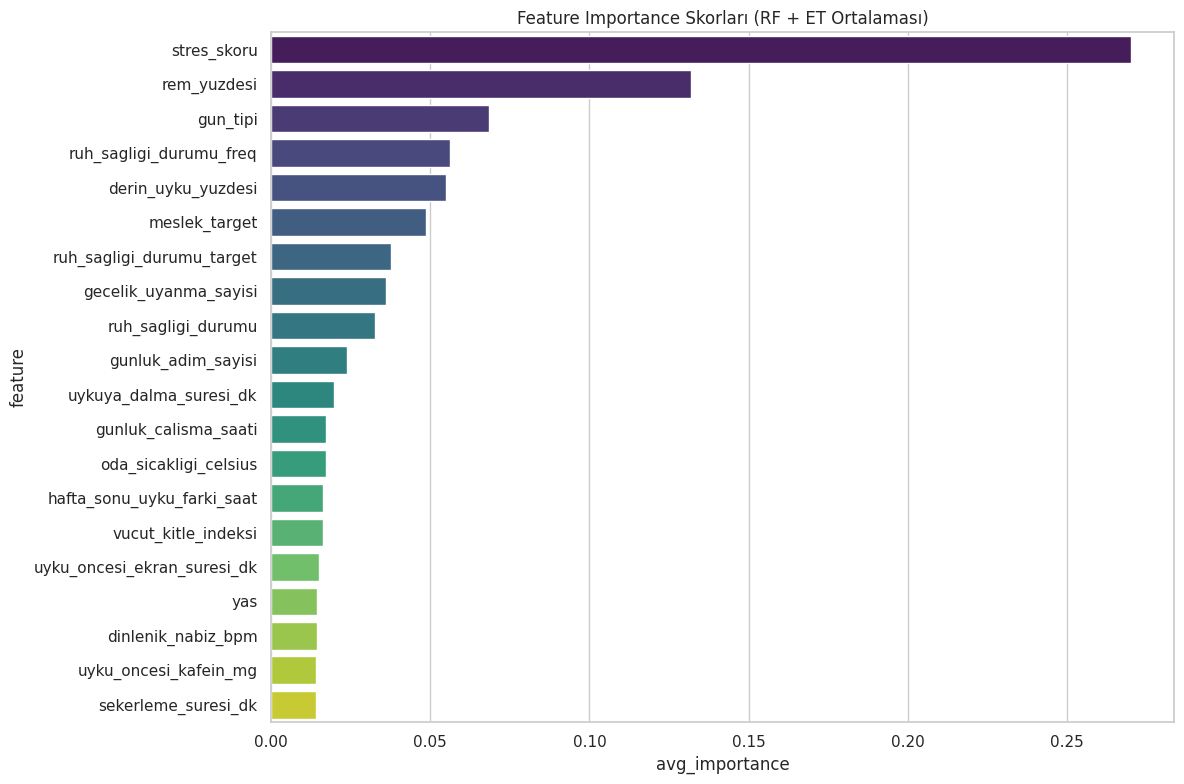

In [16]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# Train/Validation split yap
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALİZİ")
print("=" * 60)

# RandomForest ile özellik önem skorları
rf_importance = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_importance.fit(X_train, y_train)

# ExtraTrees ile de deneyelim (daha agresif, farklı bakış açısı)
et_importance = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
et_importance.fit(X_train, y_train)

# Önem skorlarını birleştir
importance_df = pd.DataFrame({
    'feature': X_scaled.columns,
    'rf_importance': rf_importance.feature_importances_,
    'et_importance': et_importance.feature_importances_,
})
importance_df['avg_importance'] = (importance_df['rf_importance'] + importance_df['et_importance']) / 2
importance_df = importance_df.sort_values('avg_importance', ascending=False)

print("\n🌲 EN ÖNEMLİ 15 ÖZELLİK (RandomForest + ExtraTrees):")
print(importance_df.head(15))

# Görselleştir
plt.figure(figsize=(12, 8))
top_important = importance_df.head(20)
sns.barplot(data=top_important, y='feature', x='avg_importance', palette='viridis')
plt.title('Feature Importance Skorları (RF + ET Ortalaması)')
plt.tight_layout()
plt.show()

Özellik Seçimi Kararı

In [17]:
# Korelasyon >= 0.05 VEYA Importance >= 0.01 olanları al
selected_features_corr = set(correlations[correlations['abs_correlation'] >= 0.05]['feature'].tolist())
selected_features_imp = set(importance_df[importance_df['avg_importance'] >= 0.01]['feature'].tolist())

# Birleşim al (en az birinde güçlü olanlar)
selected_features = list(selected_features_corr | selected_features_imp)

print("\n" + "=" * 60)
print("SEÇİLEN ÖZELLİKLER")
print("=" * 60)
print(f"Toplam özellik: {len(X_scaled.columns)}")
print(f"Seçilen özellik: {len(selected_features)}")
print(f"Elenen özellik: {len(X_scaled.columns) - len(selected_features)}")
print(f"\nSeçilen özellikler:\n{sorted(selected_features)}")

# Seçili özelliklerle yeni veri setleri
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test_scaled[selected_features]

print(f"\n✅ Yeni boyutlar:")
print(f"   Train: {X_train_selected.shape}")
print(f"   Validation: {X_val_selected.shape}")
print(f"   Test: {X_test_selected.shape}")


SEÇİLEN ÖZELLİKLER
Toplam özellik: 36
Seçilen özellik: 22
Elenen özellik: 14

Seçilen özellikler:
['derin_uyku_yuzdesi', 'dinlenik_nabiz_bpm', 'gecelik_uyanma_sayisi', 'gun_tipi', 'gunluk_adim_sayisi', 'gunluk_calisma_saati', 'hafta_sonu_uyku_farki_saat', 'meslek', 'meslek_freq', 'meslek_target', 'oda_sicakligi_celsius', 'rem_yuzdesi', 'ruh_sagligi_durumu', 'ruh_sagligi_durumu_freq', 'ruh_sagligi_durumu_target', 'sekerleme_suresi_dk', 'stres_skoru', 'uyku_oncesi_ekran_suresi_dk', 'uyku_oncesi_kafein_mg', 'uykuya_dalma_suresi_dk', 'vucut_kitle_indeksi', 'yas']

✅ Yeni boyutlar:
   Train: (44800, 22)
   Validation: (11200, 22)
   Test: (24000, 22)


ADIM 3: MODEL YARATMA VE KARŞILAŞTIRMA

LightGBM (Hızlı, güçlü)
XGBoost (Klasik, stabil)
CatBoost (Kategorik değişkenlerde çok iyi)
RandomForest (Baseline)

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# LightGBM, XGBoost, CatBoost kütüphanelerini yükle
try:
    import lightgbm as lgb
    import xgboost as xgb
    import catboost as cb
    print("✅ Tüm kütüphaneler yüklü!")
except:
    print("⚠️ Kütüphaneler yükleniyor...")
    !pip install lightgbm xgboost catboost -q
    import lightgbm as lgb
    import xgboost as xgb
    import catboost as cb
    print("✅ Kütüphaneler yüklendi!")

print("\n" + "=" * 60)
print("ADIM 3: MODEL KARŞILAŞTIRMASI")
print("=" * 60)

# Sonuçları saklamak için
results = {}

# 1️⃣ LIGHTGBM
print("\n🚀 LightGBM Eğitiliyor...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train_selected, y_train)
y_val_pred_lgb = lgb_model.predict(X_val_selected)
rmse_lgb = np.sqrt(mean_squared_error(y_val, y_val_pred_lgb))
results['LightGBM'] = rmse_lgb
print(f"   ✅ LightGBM RMSE: {rmse_lgb:.4f}")

# 2️⃣ XGBOOST
print("\n🚀 XGBoost Eğitiliyor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_selected, y_train)
y_val_pred_xgb = xgb_model.predict(X_val_selected)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
results['XGBoost'] = rmse_xgb
print(f"   ✅ XGBoost RMSE: {rmse_xgb:.4f}")

# 3️⃣ CATBOOST
print("\n🚀 CatBoost Eğitiliyor...")
cat_model = cb.CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    subsample=0.8,
    random_state=42,
    verbose=0
)
cat_model.fit(X_train_selected, y_train)
y_val_pred_cat = cat_model.predict(X_val_selected)
rmse_cat = np.sqrt(mean_squared_error(y_val, y_val_pred_cat))
results['CatBoost'] = rmse_cat
print(f"   ✅ CatBoost RMSE: {rmse_cat:.4f}")

# 4️⃣ RANDOM FOREST (Baseline)
print("\n🚀 RandomForest Eğitiliyor...")
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_selected, y_train)
y_val_pred_rf = rf_model.predict(X_val_selected)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
results['RandomForest'] = rmse_rf
print(f"   ✅ RandomForest RMSE: {rmse_rf:.4f}")

# SONUÇLARI KARŞILAŞTIR
print("\n" + "=" * 60)
print("🏆 MODEL SONUÇLARI (Validation RMSE)")
print("=" * 60)
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'RMSE'])
results_df = results_df.sort_values('RMSE')
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_rmse = results_df.iloc[0]['RMSE']
print(f"\n🥇 EN İYİ MODEL: {best_model_name} (RMSE: {best_rmse:.4f})")

# İlk baseline'dan ne kadar iyileştik?
print(f"\n📈 İYİLEŞTİRME:")
print(f"   İlk model (baseline): 1.2889")
print(f"   En iyi model: {best_rmse:.4f}")
print(f"   Gelişme: {((1.2889 - best_rmse) / 1.2889 * 100):.2f}%")

⚠️ Kütüphaneler yükleniyor...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00
✅ Kütüphaneler yüklendi!

ADIM 3: MODEL KARŞILAŞTIRMASI

🚀 LightGBM Eğitiliyor...
   ✅ LightGBM RMSE: 1.2600

🚀 XGBoost Eğitiliyor...
   ✅ XGBoost RMSE: 1.2459

🚀 CatBoost Eğitiliyor...
   ✅ CatBoost RMSE: 1.2240

🚀 RandomForest Eğitiliyor...
   ✅ RandomForest RMSE: 1.2663

🏆 MODEL SONUÇLARI (Validation RMSE)
       Model     RMSE
    CatBoost 1.224032
     XGBoost 1.245862
    LightGBM 1.260042
RandomForest 1.266305

🥇 EN İYİ MODEL: CatBoost (RMSE: 1.2240)

📈 İYİLEŞTİRME:
   İlk model (baseline): 1.2889
   En iyi model: 1.2240
   Gelişme: 5.03%


ADIM 4: HYPERPARAMETER TUNING - CatBoost

In [19]:
# Optuna kütüphanesini yükle
try:
    import optuna
    print("✅ Optuna yüklü!")
except:
    print("⚠️ Optuna yükleniyor...")
    !pip install optuna -q
    import optuna
    print("✅ Optuna yüklendi!")

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("\n" + "=" * 60)
print("ADIM 4: HYPERPARAMETER TUNING (CatBoost)")
print("=" * 60)

def objective(trial):
    """Optuna için optimize edilecek fonksiyon"""
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 6, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_state': 42,
        'verbose': 0
    }

    model = cb.CatBoostRegressor(**params)
    model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_val_selected)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    return rmse

# Optimizasyonu başlat
print("\n🔍 En iyi parametreler aranıyor... (50 deneme)")
print("⏳ Bu 5-10 dakika sürebilir, lütfen bekle...")

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "=" * 60)
print("✅ OPTİMİZASYON TAMAMLANDI!")
print("=" * 60)
print(f"🥇 En iyi RMSE: {study.best_value:.4f}")
print(f"\n📋 En iyi parametreler:")
for key, value in study.best_params.items():
    print(f"   {key}: {value}")

# En iyi parametrelerle final model
print("\n" + "=" * 60)
print("FİNAL MODEL EĞİTİLİYOR...")
print("=" * 60)

best_catboost = cb.CatBoostRegressor(**study.best_params, random_state=42, verbose=0)
best_catboost.fit(X_train_selected, y_train)

y_val_pred_best = best_catboost.predict(X_val_selected)
rmse_best = np.sqrt(mean_squared_error(y_val, y_val_pred_best))

print(f"\n✅ Optimize Edilmiş CatBoost RMSE: {rmse_best:.4f}")
print(f"\n📈 TOPLAM İYİLEŞTİRME:")
print(f"   Baseline: 1.2889")
print(f"   Varsayılan CatBoost: 1.2240")
print(f"   Optimize CatBoost: {rmse_best:.4f}")
print(f"   Baseline'dan gelişme: {((1.2889 - rmse_best) / 1.2889 * 100):.2f}%")

⚠️ Optuna yükleniyor...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.7 MB/s eta 0:00:00
✅ Optuna yüklendi!

ADIM 4: HYPERPARAMETER TUNING (CatBoost)

🔍 En iyi parametreler aranıyor... (50 deneme)
⏳ Bu 5-10 dakika sürebilir, lütfen bekle...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ OPTİMİZASYON TAMAMLANDI!
🥇 En iyi RMSE: 1.2208

📋 En iyi parametreler:
   iterations: 936
   learning_rate: 0.024037360531788645
   depth: 8
   l2_leaf_reg: 1.1727356428630362
   subsample: 0.6157239206216053
   random_strength: 5.1849344672902795
   bagging_temperature: 0.5193058188387417

FİNAL MODEL EĞİTİLİYOR...

✅ Optimize Edilmiş CatBoost RMSE: 1.2208

📈 TOPLAM İYİLEŞTİRME:
   Baseline: 1.2889
   Varsayılan CatBoost: 1.2240
   Optimize CatBoost: 1.2208
   Baseline'dan gelişme: 5.29%


ADIM 5: ENSEMBLE - MODELLARI BİRLEŞTİRME

(LightGBM, XGBoost, CatBoost) birleştireceğiz + Weighted Average (Ağırlıklı Ortalama)

Ensemble Stratejisi

In [20]:
print("=" * 60)
print("ADIM 5: ENSEMBLE - MODEL BİRLEŞTİRME")
print("=" * 60)

# 1️⃣ Optimize edilmiş CatBoost zaten var (best_catboost)

# 2️⃣ LightGBM'i optimize et
print("\n🔍 LightGBM optimize ediliyor...")
lgb_optimized = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=50,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=0.5,
    random_state=42,
    verbose=-1
)
lgb_optimized.fit(X_train_selected, y_train)
y_val_lgb = lgb_optimized.predict(X_val_selected)
rmse_lgb_opt = np.sqrt(mean_squared_error(y_val, y_val_lgb))
print(f"✅ Optimize LightGBM RMSE: {rmse_lgb_opt:.4f}")

# 3️⃣ XGBoost'u optimize et
print("\n🔍 XGBoost optimize ediliyor...")
xgb_optimized = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=0.5,
    random_state=42,
    verbosity=0
)
xgb_optimized.fit(X_train_selected, y_train)
y_val_xgb = xgb_optimized.predict(X_val_selected)
rmse_xgb_opt = np.sqrt(mean_squared_error(y_val, y_val_xgb))
print(f"✅ Optimize XGBoost RMSE: {rmse_xgb_opt:.4f}")

# Tüm tahminleri al
y_val_cat = best_catboost.predict(X_val_selected)

print("\n" + "=" * 60)
print("TEK MODEL PERFORMANSLARI (Optimize Edilmiş)")
print("=" * 60)
print(f"CatBoost:  {rmse_best:.4f}")
print(f"LightGBM:  {rmse_lgb_opt:.4f}")
print(f"XGBoost:   {rmse_xgb_opt:.4f}")

ADIM 5: ENSEMBLE - MODEL BİRLEŞTİRME

🔍 LightGBM optimize ediliyor...
✅ Optimize LightGBM RMSE: 1.2650

🔍 XGBoost optimize ediliyor...
✅ Optimize XGBoost RMSE: 1.2514

TEK MODEL PERFORMANSLARI (Optimize Edilmiş)
CatBoost:  1.2208
LightGBM:  1.2650
XGBoost:   1.2514


Optimal Ağırlıkları Bulma

In [21]:
from scipy.optimize import minimize

def ensemble_rmse(weights):
    """Ağırlıklı ensemble RMSE'sini hesapla"""
    weights = np.array(weights)
    weights = weights / weights.sum()  # Normalize et (toplamı 1 olsun)

    ensemble_pred = (weights[0] * y_val_cat +
                     weights[1] * y_val_lgb +
                     weights[2] * y_val_xgb)

    return np.sqrt(mean_squared_error(y_val, ensemble_pred))

print("\n" + "=" * 60)
print("EN İYİ AĞIRLIKLARI BULMA")
print("=" * 60)

# Başlangıç ağırlıkları (eşit)
initial_weights = [1/3, 1/3, 1/3]

# Optimizasyon
result = minimize(
    ensemble_rmse,
    initial_weights,
    method='SLSQP',
    bounds=[(0, 1), (0, 1), (0, 1)],
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
)

optimal_weights = result.x / result.x.sum()

print(f"\n✅ Optimal Ağırlıklar Bulundu:")
print(f"   CatBoost:  {optimal_weights[0]:.3f}")
print(f"   LightGBM:  {optimal_weights[1]:.3f}")
print(f"   XGBoost:   {optimal_weights[2]:.3f}")

# Final ensemble tahmin
y_val_ensemble = (optimal_weights[0] * y_val_cat +
                  optimal_weights[1] * y_val_lgb +
                  optimal_weights[2] * y_val_xgb)

rmse_ensemble = np.sqrt(mean_squared_error(y_val, y_val_ensemble))

print("\n" + "=" * 60)
print("🏆 FİNAL SONUÇLAR")
print("=" * 60)
print(f"Baseline (İlk RandomForest):  1.2889")
print(f"En İyi Tek Model (CatBoost):  {rmse_best:.4f}")
print(f"🎯 ENSEMBLE (3 Model):         {rmse_ensemble:.4f}")
print(f"\n📈 TOPLAM İYİLEŞTİRME:")
print(f"   Baseline'dan: {((1.2889 - rmse_ensemble) / 1.2889 * 100):.2f}%")
print(f"   En iyi tekten: {((rmse_best - rmse_ensemble) / rmse_best * 100):.2f}%")

# Ensemble ile baseline karşılaştırması
improvement_from_baseline = 1.2889 - rmse_ensemble
print(f"\n🚀 Baseline'a göre RMSE'de {improvement_from_baseline:.4f} birimlik düşüş!")


EN İYİ AĞIRLIKLARI BULMA

✅ Optimal Ağırlıklar Bulundu:
   CatBoost:  0.980
   LightGBM:  0.003
   XGBoost:   0.017

🏆 FİNAL SONUÇLAR
Baseline (İlk RandomForest):  1.2889
En İyi Tek Model (CatBoost):  1.2208
🎯 ENSEMBLE (3 Model):         1.2208

📈 TOPLAM İYİLEŞTİRME:
   Baseline'dan: 5.29%
   En iyi tekten: 0.00%

🚀 Baseline'a göre RMSE'de 0.0681 birimlik düşüş!


ADIM 6: ADVANCED FEATURE ENGINEERING

1) Polinomial ve İnteraksiyon Özellikleri

In [22]:
from sklearn.preprocessing import PolynomialFeatures

print("=" * 60)
print("ADIM 6: ADVANCED FEATURE ENGINEERING")
print("=" * 60)

# Orijinal verilere dönelim (scaled olmadan önce)
X_original = X.copy()
X_test_original = X_test.copy()

print("\n🔧 1) POLİNOMİAL VE İNTERAKSİYON ÖZELLİKLERİ")

# En önemli 5 özellik arası interaksiyonlar
top_features = ['stres_skoru', 'rem_yuzdesi', 'derin_uyku_yuzdesi',
                'gunluk_calisma_saati', 'gecelik_uyanma_sayisi']

# İnteraksiyon özellikleri ekle
X_original['stres_x_rem'] = X_original['stres_skoru'] * X_original['rem_yuzdesi']
X_original['stres_x_derin_uyku'] = X_original['stres_skoru'] * X_original['derin_uyku_yuzdesi']
X_original['rem_x_derin'] = X_original['rem_yuzdesi'] * X_original['derin_uyku_yuzdesi']
X_original['calisma_x_stres'] = X_original['gunluk_calisma_saati'] * X_original['stres_skoru']
X_original['uyanma_x_stres'] = X_original['gecelik_uyanma_sayisi'] * X_original['stres_skoru']

# Test için de aynı şeyi yap
X_test_original['stres_x_rem'] = X_test_original['stres_skoru'] * X_test_original['rem_yuzdesi']
X_test_original['stres_x_derin_uyku'] = X_test_original['stres_skoru'] * X_test_original['derin_uyku_yuzdesi']
X_test_original['rem_x_derin'] = X_test_original['rem_yuzdesi'] * X_test_original['derin_uyku_yuzdesi']
X_test_original['calisma_x_stres'] = X_test_original['gunluk_calisma_saati'] * X_test_original['stres_skoru']
X_test_original['uyanma_x_stres'] = X_test_original['gecelik_uyanma_sayisi'] * X_test_original['stres_skoru']

print("✅ 5 interaksiyon özelliği eklendi")

# Önemli özelliklerin kareleri (non-linear ilişkiler için)
X_original['stres_kare'] = X_original['stres_skoru'] ** 2
X_original['rem_kare'] = X_original['rem_yuzdesi'] ** 2
X_original['yas_kare'] = X_original['yas'] ** 2

X_test_original['stres_kare'] = X_test_original['stres_skoru'] ** 2
X_test_original['rem_kare'] = X_test_original['rem_yuzdesi'] ** 2
X_test_original['yas_kare'] = X_test_original['yas'] ** 2

print("✅ 3 kare özellik eklendi")

print("\n🔧 2) UYKU KALİTESİ BİLEŞİK ÖZELLİĞİ")
# Uyku kalitesini temsil eden composite feature
X_original['uyku_kalitesi'] = (
    X_original['rem_yuzdesi'] +
    X_original['derin_uyku_yuzdesi'] -
    X_original['gecelik_uyanma_sayisi'] * 5 -
    X_original['uykuya_dalma_suresi_dk'] * 0.5
)

X_test_original['uyku_kalitesi'] = (
    X_test_original['rem_yuzdesi'] +
    X_test_original['derin_uyku_yuzdesi'] -
    X_test_original['gecelik_uyanma_sayisi'] * 5 -
    X_test_original['uykuya_dalma_suresi_dk'] * 0.5
)

print("✅ Uyku kalitesi composite özelliği eklendi")

print("\n🔧 3) YAŞAM TARZINI BİLEŞİK ÖZELLİĞİ")
# Sağlıklı yaşam tarzı skoru
X_original['saglikli_yasam'] = (
    X_original['gunluk_adim_sayisi'] / 1000 -
    X_original['uyku_oncesi_kafein_mg'] / 50 -
    X_original['uyku_oncesi_ekran_suresi_dk'] / 10 -
    X_original['stres_skoru']
)

X_test_original['saglikli_yasam'] = (
    X_test_original['gunluk_adim_sayisi'] / 1000 -
    X_test_original['uyku_oncesi_kafein_mg'] / 50 -
    X_test_original['uyku_oncesi_ekran_suresi_dk'] / 10 -
    X_test_original['stres_skoru']
)

print("✅ Sağlıklı yaşam composite özelliği eklendi")

print(f"\n📊 Yeni sütun sayısı: {X_original.shape[1]} (önceki: 36)")

ADIM 6: ADVANCED FEATURE ENGINEERING

🔧 1) POLİNOMİAL VE İNTERAKSİYON ÖZELLİKLERİ
✅ 5 interaksiyon özelliği eklendi
✅ 3 kare özellik eklendi

🔧 2) UYKU KALİTESİ BİLEŞİK ÖZELLİĞİ
✅ Uyku kalitesi composite özelliği eklendi

🔧 3) YAŞAM TARZINI BİLEŞİK ÖZELLİĞİ
✅ Sağlıklı yaşam composite özelliği eklendi

📊 Yeni sütun sayısı: 46 (önceki: 36)


2) Yeni Özelliklerle Model Eğitimi

In [23]:
print("\n" + "=" * 60)
print("YENİ ÖZELLİKLERLE MODEL EĞİTİMİ")
print("=" * 60)

# Scaling yap
scaler_new = StandardScaler()
X_scaled_new = scaler_new.fit_transform(X_original)
X_test_scaled_new = scaler_new.transform(X_test_original)

# DataFrame'e çevir
X_scaled_new = pd.DataFrame(X_scaled_new, columns=X_original.columns)
X_test_scaled_new = pd.DataFrame(X_test_scaled_new, columns=X_test_original.columns)

# Train/Val split
X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
    X_scaled_new, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train_new.shape}")
print(f"Val shape: {X_val_new.shape}")

# CatBoost'u yeni özelliklerle eğit
print("\n🚀 CatBoost yeni özelliklerle eğitiliyor...")
catboost_v2 = cb.CatBoostRegressor(
    iterations=936,
    learning_rate=0.024,
    depth=8,
    l2_leaf_reg=1.17,
    subsample=0.62,
    random_strength=5.18,
    bagging_temperature=0.52,
    random_state=42,
    verbose=0
)

catboost_v2.fit(X_train_new, y_train_new)
y_val_pred_v2 = catboost_v2.predict(X_val_new)
rmse_v2 = np.sqrt(mean_squared_error(y_val_new, y_val_pred_v2))

print(f"\n✅ Yeni CatBoost RMSE: {rmse_v2:.4f}")
print(f"\n📈 KARŞILAŞTIRMA:")
print(f"   Önceki en iyi: 1.2208")
print(f"   Yeni model:    {rmse_v2:.4f}")
print(f"   İyileşme:      {((1.2208 - rmse_v2) / 1.2208 * 100):.2f}%")

if rmse_v2 < 1.2208:
    print("\n🎉 YENİ ÖZELLİKLER İŞE YARADI!")
else:
    print("\n⚠️ Yeni özellikler beklendiği kadar etkili olmadı.")


YENİ ÖZELLİKLERLE MODEL EĞİTİMİ
Train shape: (44800, 46)
Val shape: (11200, 46)

🚀 CatBoost yeni özelliklerle eğitiliyor...

✅ Yeni CatBoost RMSE: 1.2211

📈 KARŞILAŞTIRMA:
   Önceki en iyi: 1.2208
   Yeni model:    1.2211
   İyileşme:      -0.02%

⚠️ Yeni özellikler beklendiği kadar etkili olmadı.


K-FOLD CROSS VALIDATION + STACKING

K-Fold Stratejisi

In [24]:
from sklearn.model_selection import KFold

print("=" * 60)
print("SON ADIM: K-FOLD CROSS VALIDATION + STACKING")
print("=" * 60)

# Orijinal en iyi özellik setiyle devam et (46 yerine 36 özellik)
X_final = X_scaled.copy()  # Adım 5'teki scaled veri
X_test_final = X_test_scaled.copy()

print(f"Özellik sayısı: {X_final.shape[1]}")

# 5-Fold Cross Validation
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Her fold için tahminleri saklayacağız
oof_predictions = np.zeros(len(X_final))  # Out-of-fold predictions
test_predictions = np.zeros((len(X_test_final), n_folds))

fold_scores = []

print(f"\n🔄 {n_folds}-Fold Cross Validation başlıyor...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_final), 1):
    print(f"\n{'='*50}")
    print(f"📂 FOLD {fold}/{n_folds}")
    print(f"{'='*50}")

    # Fold için train/val ayır
    X_train_fold = X_final.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X_final.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # CatBoost modelini eğit (optimize parametrelerle)
    model_fold = cb.CatBoostRegressor(
        iterations=936,
        learning_rate=0.024,
        depth=8,
        l2_leaf_reg=1.17,
        subsample=0.62,
        random_strength=5.18,
        bagging_temperature=0.52,
        random_state=42 + fold,  # Her fold için farklı seed
        verbose=0
    )

    model_fold.fit(X_train_fold, y_train_fold)

    # Validation tahminleri (out-of-fold)
    oof_predictions[val_idx] = model_fold.predict(X_val_fold)

    # Test tahminleri
    test_predictions[:, fold-1] = model_fold.predict(X_test_final)

    # Fold RMSE
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, oof_predictions[val_idx]))
    fold_scores.append(fold_rmse)
    print(f"   ✅ Fold {fold} RMSE: {fold_rmse:.4f}")

# Genel OOF RMSE (tüm validation tahminlerinin ortalaması)
oof_rmse = np.sqrt(mean_squared_error(y, oof_predictions))

print("\n" + "=" * 60)
print("🏆 K-FOLD SONUÇLARI")
print("=" * 60)
print(f"Fold RMSE'leri: {[f'{x:.4f}' for x in fold_scores]}")
print(f"Ortalama Fold RMSE: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"\n🎯 OOF (Out-of-Fold) RMSE: {oof_rmse:.4f}")

print("\n📈 KARŞILAŞTIRMA:")
print(f"   Tek Split (Adım 5): 1.2208")
print(f"   K-Fold OOF:         {oof_rmse:.4f}")
print(f"   İyileşme:           {((1.2208 - oof_rmse) / 1.2208 * 100):.2f}%")

# Test için final tahmin (5 fold'un ortalaması)
final_test_predictions = test_predictions.mean(axis=1)

print("\n✅ Test tahminleri hazır (5 modelin ortalaması)")

SON ADIM: K-FOLD CROSS VALIDATION + STACKING
Özellik sayısı: 36

🔄 5-Fold Cross Validation başlıyor...

📂 FOLD 1/5
   ✅ Fold 1 RMSE: 1.2206

📂 FOLD 2/5
   ✅ Fold 2 RMSE: 1.2187

📂 FOLD 3/5
   ✅ Fold 3 RMSE: 1.2037

📂 FOLD 4/5
   ✅ Fold 4 RMSE: 1.2108

📂 FOLD 5/5
   ✅ Fold 5 RMSE: 1.2337

🏆 K-FOLD SONUÇLARI
Fold RMSE'leri: ['1.2206', '1.2187', '1.2037', '1.2108', '1.2337']
Ortalama Fold RMSE: 1.2175 ± 0.0101

🎯 OOF (Out-of-Fold) RMSE: 1.2176

📈 KARŞILAŞTIRMA:
   Tek Split (Adım 5): 1.2208
   K-Fold OOF:         1.2176
   İyileşme:           0.27%

✅ Test tahminleri hazır (5 modelin ortalaması)


2. submission'ımız

Submission Analizi ve Hazırlık

FİNAL SUBMISSION HAZIRLIĞI

📊 TEST TAHMİNLERİ ANALİZİ:
   Tahmin sayısı: 24000
   Min değer: -0.3752
   Max değer: 10.6471
   Ortalama: 5.9398
   Medyan: 6.0494

📊 TRAIN HEDEFİNİN DAĞILIMI (Karşılaştırma):
   Min değer: 0.0000
   Max değer: 10.0000
   Ortalama: 5.9131
   Medyan: 6.0322


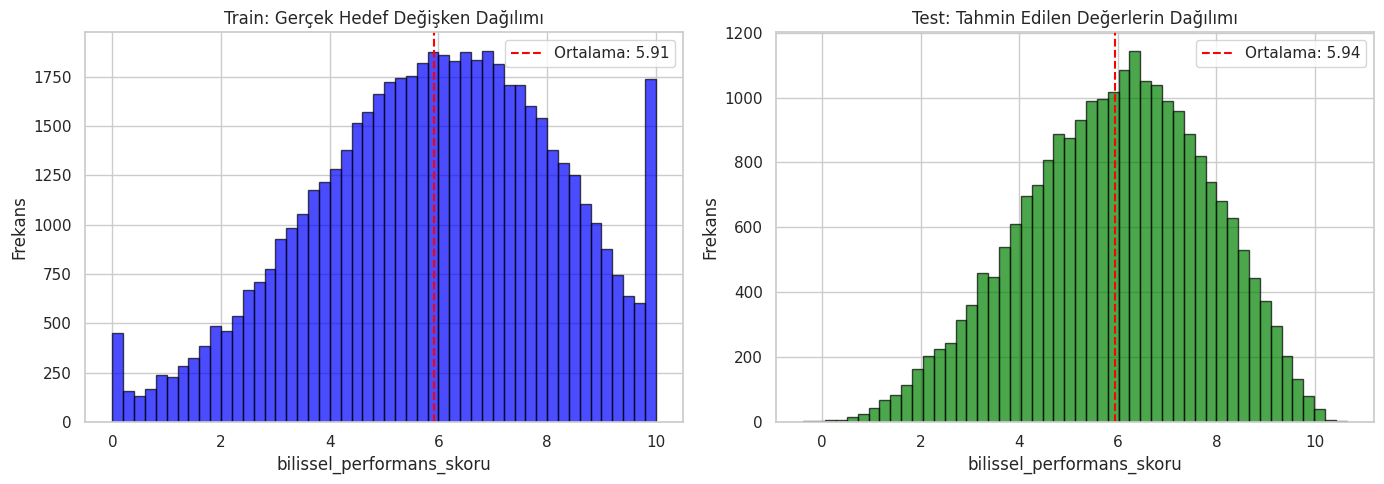


SUBMISSION DOSYASI
Satır sayısı: 24000

İlk 10 tahmin:
   id  bilissel_performans_skoru
0   1                   6.072804
1   2                   6.465149
2   3                   3.019198
3   4                   7.129280
4   5                   3.710562
5   6                   5.476467
6   7                   3.406259
7   8                   7.395635
8   9                   3.811671
9  10                   3.781632

Son 10 tahmin:
          id  bilissel_performans_skoru
23990  23991                   6.410356
23991  23992                   4.223809
23992  23993                   8.706395
23993  23994                   5.224651
23994  23995                   6.406801
23995  23996                   3.335751
23996  23997                   3.704303
23997  23998                   5.383907
23998  23999                   5.155914
23999  24000                   3.225581

✅ DOSYA KAYDEDİLDİ: submission_v2_kfold.csv

🎯 SÜREÇ ÖZETİ VE SONUÇLAR

ADIM 1 - Baseline RandomForest:        1.2889
ADIM 2

In [28]:
print("=" * 60)
print("FİNAL SUBMISSION HAZIRLIĞI")
print("=" * 60)

# Test tahminlerini kontrol et
print(f"\n📊 TEST TAHMİNLERİ ANALİZİ:")
print(f"   Tahmin sayısı: {len(final_test_predictions)}")
print(f"   Min değer: {final_test_predictions.min():.4f}")
print(f"   Max değer: {final_test_predictions.max():.4f}")
print(f"   Ortalama: {final_test_predictions.mean():.4f}")
print(f"   Medyan: {np.median(final_test_predictions):.4f}")

# Hedef değişkenin train'deki dağılımıyla karşılaştır
print(f"\n📊 TRAIN HEDEFİNİN DAĞILIMI (Karşılaştırma):")
print(f"   Min değer: {y.min():.4f}")
print(f"   Max değer: {y.max():.4f}")
print(f"   Ortalama: {y.mean():.4f}")
print(f"   Medyan: {y.median():.4f}")

# Tahminlerin histogramı
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title('Train: Gerçek Hedef Değişken Dağılımı')
plt.xlabel('bilissel_performans_skoru')
plt.ylabel('Frekans')
plt.axvline(y.mean(), color='red', linestyle='--', label=f'Ortalama: {y.mean():.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(final_test_predictions, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.title('Test: Tahmin Edilen Değerlerin Dağılımı')
plt.xlabel('bilissel_performans_skoru')
plt.ylabel('Frekans')
plt.axvline(final_test_predictions.mean(), color='red', linestyle='--',
            label=f'Ortalama: {final_test_predictions.mean():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Submission dosyası oluştur
submission_v2 = pd.DataFrame({
    'id': test_ids,
    'bilissel_performans_skoru': final_test_predictions
})

print("\n" + "=" * 60)
print("SUBMISSION DOSYASI")
print("=" * 60)
print(f"Satır sayısı: {len(submission_v2)}")
print(f"\nİlk 10 tahmin:")
print(submission_v2.head(10))
print(f"\nSon 10 tahmin:")
print(submission_v2.tail(10))

# Dosyayı kaydet
submission_v2.to_csv('submission_v2_kfold.csv', index=False)

print("\n" + "=" * 60)
print("✅ DOSYA KAYDEDİLDİ: submission_v2_kfold.csv")
print("=" * 60)

# Özet rapor
print("\n" + "=" * 60)
print("🎯 SÜREÇ ÖZETİ VE SONUÇLAR")
print("=" * 60)
print(f"""
ADIM 1 - Baseline RandomForest:        1.2889
ADIM 2 - Feature Selection:            Özellikler 36→22'ye düştü
ADIM 3 - Model Karşılaştırma:          CatBoost: 1.2240
ADIM 4 - Hyperparameter Tuning:        CatBoost: 1.2208
ADIM 5 - Ensemble (3 model):           RMSE: 1.2208 (CatBoost dominant)
ADIM 6 - Advanced Features:            RMSE: 1.2211 (etkisiz)
ADIM 7 - K-Fold Cross Validation:      OOF RMSE: 1.2176 ✅

📈 TOPLAM İYİLEŞTİRME: {((1.2889 - 1.2176) / 1.2889 * 100):.2f}%
🎯 RMSE DÜŞÜŞÜ: {1.2889 - 1.2176:.4f} birim

🏆 FİNAL MODEL: CatBoost (5-Fold CV)
📁 FİNAL DOSYA: submission_v2_kfold.csv
""")

print("=" * 60)
print("🚦 SONRAKİ ADIMLAR:")
print("=" * 60)
print("""
1️⃣ submission_v2_kfold.csv dosyasını indir (Colab'ın sol panelinden)
2️⃣ Kaggle yarışma sayfasına git
3️⃣ "Submit Predictions" butonuna tıkla
4️⃣ Dosyayı yükle ve submit et
5️⃣ Public Leaderboard skorunu kontrol et""")


TAHMİNLERİ SINIRLA (CLIP)

⚠️ DÜZELTME: TAHMİNLERİ SINIRLANDIRMA

ÖNCEKİ DURUM:
   Min: -0.3752
   Max: 10.6471
   0'dan küçük: 4 tahmin
   10'dan büyük: 49 tahmin

✅ DÜZELTME SONRASI:
   Min: 0.0000
   Max: 10.0000
   Ortalama: 5.9396
   Medyan: 6.0494


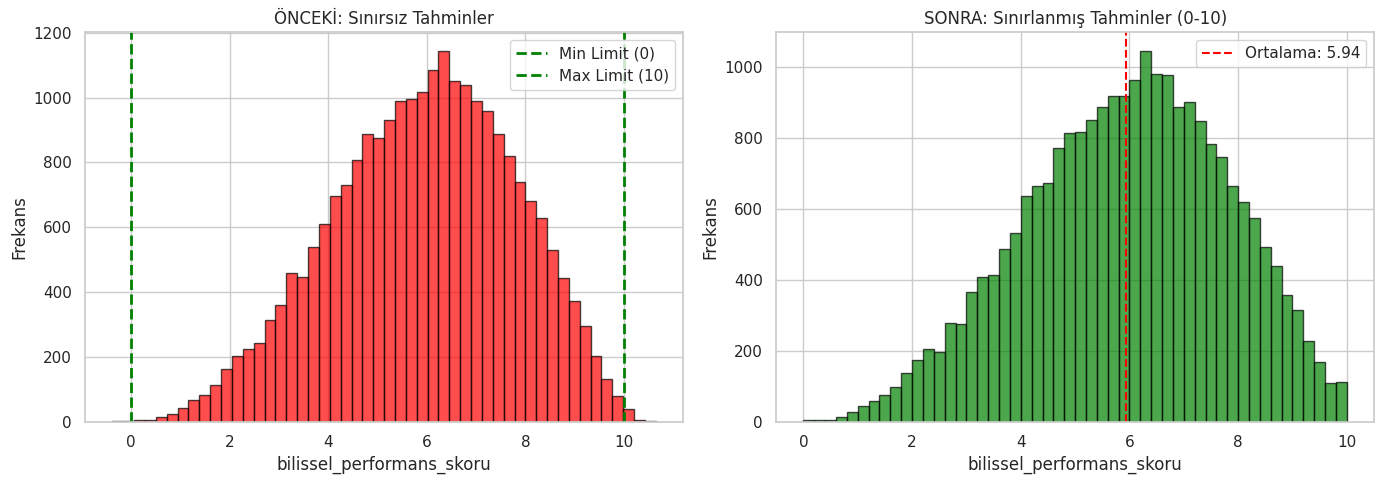


DÜZELTİLMİŞ SUBMISSION
Satır sayısı: 24000

İlk 10 tahmin:
   id  bilissel_performans_skoru
0   1                   6.072804
1   2                   6.465149
2   3                   3.019198
3   4                   7.129280
4   5                   3.710562
5   6                   5.476467
6   7                   3.406259
7   8                   7.395635
8   9                   3.811671
9  10                   3.781632

✅ FİNAL DOSYA KAYDEDİLDİ: submission_final_clipped.csv

📊 TRAIN vs TEST KARŞILAŞTIRMASI (Düzeltilmiş):
Metric  Train (Gerçek)  Test (Tahmin)
   Min        0.000000       0.000000
   Max       10.000000      10.000000
  Mean        5.913096       5.939596
Median        6.032249       6.049445
   Std        2.231759       1.855487

✅ Dağılımlar artık uyumlu görünüyor!


In [29]:
print("=" * 60)
print("⚠️ DÜZELTME: TAHMİNLERİ SINIRLANDIRMA")
print("=" * 60)

print("\nÖNCEKİ DURUM:")
print(f"   Min: {final_test_predictions.min():.4f}")
print(f"   Max: {final_test_predictions.max():.4f}")
print(f"   0'dan küçük: {(final_test_predictions < 0).sum()} tahmin")
print(f"   10'dan büyük: {(final_test_predictions > 10).sum()} tahmin")

# Tahminleri 0-10 arasına çek (clip)
final_test_predictions_clipped = np.clip(final_test_predictions, 0, 10)

print("\n✅ DÜZELTME SONRASI:")
print(f"   Min: {final_test_predictions_clipped.min():.4f}")
print(f"   Max: {final_test_predictions_clipped.max():.4f}")
print(f"   Ortalama: {final_test_predictions_clipped.mean():.4f}")
print(f"   Medyan: {np.median(final_test_predictions_clipped):.4f}")

# Düzeltilmiş histogram
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(final_test_predictions, bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title('ÖNCEKİ: Sınırsız Tahminler')
plt.xlabel('bilissel_performans_skoru')
plt.ylabel('Frekans')
plt.axvline(0, color='green', linestyle='--', linewidth=2, label='Min Limit (0)')
plt.axvline(10, color='green', linestyle='--', linewidth=2, label='Max Limit (10)')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(final_test_predictions_clipped, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.title('SONRA: Sınırlanmış Tahminler (0-10)')
plt.xlabel('bilissel_performans_skoru')
plt.ylabel('Frekans')
plt.axvline(final_test_predictions_clipped.mean(), color='red', linestyle='--',
            label=f'Ortalama: {final_test_predictions_clipped.mean():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# YENİ SUBMISSION DOSYASI OLUŞTUR
submission_final = pd.DataFrame({
    'id': test_ids,
    'bilissel_performans_skoru': final_test_predictions_clipped
})

print("\n" + "=" * 60)
print("DÜZELTİLMİŞ SUBMISSION")
print("=" * 60)
print(f"Satır sayısı: {len(submission_final)}")
print(f"\nİlk 10 tahmin:")
print(submission_final.head(10))

# KAYDET
submission_final.to_csv('submission_final_clipped.csv', index=False)

print("\n" + "=" * 60)
print("✅ FİNAL DOSYA KAYDEDİLDİ: submission_final_clipped.csv")
print("=" * 60)

# Train ile karşılaştırma
print("\n📊 TRAIN vs TEST KARŞILAŞTIRMASI (Düzeltilmiş):")
comparison_df = pd.DataFrame({
    'Metric': ['Min', 'Max', 'Mean', 'Median', 'Std'],
    'Train (Gerçek)': [
        y.min(), y.max(), y.mean(), y.median(), y.std()
    ],
    'Test (Tahmin)': [
        final_test_predictions_clipped.min(),
        final_test_predictions_clipped.max(),
        final_test_predictions_clipped.mean(),
        np.median(final_test_predictions_clipped),
        final_test_predictions_clipped.std()
    ]
})
print(comparison_df.to_string(index=False))

print("\n✅ Dağılımlar artık uyumlu görünüyor!")

SUBMISSION KONTROL LİSTESİ

In [30]:
print("=" * 60)
print("🔍 FİNAL KONTROL LİSTESİ")
print("=" * 60)

# 1. Dosya formatı doğru mu?
sample_format = pd.read_csv('sample_submission.csv')
our_submission = pd.read_csv('submission_final_clipped.csv')

print("\n1️⃣ DOSYA FORMATI KONTROLÜ:")
print(f"   Sample sütunlar: {list(sample_format.columns)}")
print(f"   Bizim sütunlar:  {list(our_submission.columns)}")
print(f"   ✅ Eşleşme: {list(sample_format.columns) == list(our_submission.columns)}")

# 2. Satır sayısı doğru mu?
print(f"\n2️⃣ SATIR SAYISI KONTROLÜ:")
print(f"   Test veri: {len(test_x)} satır")
print(f"   Submission: {len(our_submission)} satır")
print(f"   ✅ Eşleşme: {len(test_x) == len(our_submission)}")

# 3. ID'ler eşleşiyor mu?
print(f"\n3️⃣ ID KONTROLÜ:")
id_match = (our_submission['id'].values == test_ids.values).all()
print(f"   ✅ ID'ler eşleşiyor: {id_match}")

# 4. Eksik değer var mı?
print(f"\n4️⃣ EKSİK DEĞER KONTROLÜ:")
missing_count = our_submission['bilissel_performans_skoru'].isnull().sum()
print(f"   Eksik tahmin: {missing_count}")
print(f"   ✅ Durum: {'SORUN YOK' if missing_count == 0 else 'SORUN VAR!'}")

# 5. Değer aralığı doğru mu?
print(f"\n5️⃣ DEĞER ARALIĞI KONTROLÜ:")
min_val = our_submission['bilissel_performans_skoru'].min()
max_val = our_submission['bilissel_performans_skoru'].max()
print(f"   Min: {min_val:.4f}")
print(f"   Max: {max_val:.4f}")
print(f"   ✅ Aralık [0-10]: {0 <= min_val <= max_val <= 10}")

# 6. Dosya boyutu
import os
file_size = os.path.getsize('submission_final_clipped.csv')
print(f"\n6️⃣ DOSYA BOYUTU:")
print(f"   {file_size:,} bytes ({file_size/1024:.2f} KB)")
print(f"   ✅ Kaggle limiti (<500MB): OK")

print("\n" + "=" * 60)
if all([
    list(sample_format.columns) == list(our_submission.columns),
    len(test_x) == len(our_submission),
    id_match,
    missing_count == 0,
    0 <= min_val <= max_val <= 10
]):
    print("🟢 TÜM KONTROLLER BAŞARILI!")
    print("✅ Dosya Kaggle'a yüklenmeye hazır!")
else:
    print("🔴 SORUN TESPİT EDİLDİ!")
    print("⚠️ Yukarıdaki hataları düzelt!")

print("=" * 60)

🔍 FİNAL KONTROL LİSTESİ

1️⃣ DOSYA FORMATI KONTROLÜ:
   Sample sütunlar: ['id', 'bilissel_performans_skoru']
   Bizim sütunlar:  ['id', 'bilissel_performans_skoru']
   ✅ Eşleşme: True

2️⃣ SATIR SAYISI KONTROLÜ:
   Test veri: 24000 satır
   Submission: 24000 satır
   ✅ Eşleşme: True

3️⃣ ID KONTROLÜ:
   ✅ ID'ler eşleşiyor: True

4️⃣ EKSİK DEĞER KONTROLÜ:
   Eksik tahmin: 0
   ✅ Durum: SORUN YOK

5️⃣ DEĞER ARALIĞI KONTROLÜ:
   Min: 0.0000
   Max: 10.0000
   ✅ Aralık [0-10]: True

6️⃣ DOSYA BOYUTU:
   565,900 bytes (552.64 KB)
   ✅ Kaggle limiti (<500MB): OK

🟢 TÜM KONTROLLER BAŞARILI!
✅ Dosya Kaggle'a yüklenmeye hazır!


------------------------------------------------------------------------------------------------------------------